# Life Expectancy — Visual Insight Engine
### DATA-VIZ HACK-A-BIT 2025-2026 | Team 2 | 24ADI004
**Course:** 24ADI204 — Data Science and Visualization  
**Dataset:** WHO Life Expectancy Data (2000–2015) | 193 Countries | 22 Features

---


---
## Week 1 — Team Formation, Environment Setup & Data Ingestion

**Objective:** Set up the project environment, load the dataset, and perform a first-pass structural inspection.

### Libraries Overview

- **pandas** — Data loading, manipulation, and tabular operations
- **numpy** — Numerical computing and array operations
- **matplotlib** — Low-level plotting and chart customization
- **seaborn** — High-level statistical visualizations built on matplotlib
- **sklearn** — Machine learning preprocessing (scaling, PCA, encoding)
- **warnings** — Suppress non-critical runtime warnings for cleaner output


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

PALETTE=['#FF6B6B','#FFA07A','#FFD93D','#6BCB77','#4D96FF',
         '#C77DFF','#FF9FF3','#48CAE4','#F4A261','#2EC4B6']
HEAT_CMAP='RdYlGn'
SEQ_CMAP='plasma'
BG_COLOR='#FAFAFA'

plt.rcParams.update({
    'figure.facecolor':BG_COLOR,
    'axes.facecolor':BG_COLOR,
    'axes.grid':True,
    'grid.alpha':0.3,
    'axes.spines.top':False,
    'axes.spines.right':False,
    'font.family':'DejaVu Sans',
    'axes.titlesize':14,
    'axes.titleweight':'bold',
    'axes.labelsize':11,
})
sns.set_style('whitegrid')
print('Libraries loaded | Style configured | Ready for Week 1')


Libraries loaded | Style configured | Ready for Week 1


All essential libraries are loaded and a global plot style is applied. The custom palette uses 10 distinct colours reused across every chart for visual consistency. The `rcParams` block standardises font sizes, background colours, and axis styles project-wide.


---
### Data Ingestion — Loading the Raw Dataset

The dataset is the **WHO Life Expectancy dataset** sourced from Kaggle/UCI. It covers **193 countries across 16 years (2000–2015)** with 22 health, economic, and demographic indicators.

**Ingestion Strategy:** The CSV is loaded using `pd.read_csv`, trailing whitespace is stripped from column names (a known quirk of this dataset), and the structure is immediately inspected.


In [6]:
df=pd.read_csv("Life Expectancy Data.csv")
df.columns=df.columns.str.strip()

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)
print(f"  Shape            : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  Unique Countries : {df['Country'].nunique()}")
print(f"  Year Range       : {df['Year'].min()} - {df['Year'].max()}")
print(f"  Status Types     : {list(df['Status'].unique())}")
print(f"  Memory Usage     : {df.memory_usage(deep=True).sum()/1024:.1f} KB")
print("="*60)
print("\nColumn Names & Data Types:")
print(df.dtypes.to_string())
print("\nFirst 10 Rows:")
display(df.head(10))
print("\nLast 10 Rows:")
display(df.tail(10))


DATASET LOADED SUCCESSFULLY
  Shape            : 2,938 rows x 22 columns
  Unique Countries : 193
  Year Range       : 2000 - 2015
  Status Types     : ['Developing', 'Developed']
  Memory Usage     : 797.9 KB

Column Names & Data Types:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                     

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1



Last 10 Rows:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2928,Zimbabwe,2009,Developing,50.0,587.0,30,4.64,1.040021,73.0,853,...,69.0,6.26,73.0,18.1,65.824121,1381599.0,7.5,7.4,0.419,9.9
2929,Zimbabwe,2008,Developing,48.2,632.0,30,3.56,20.843429,75.0,0,...,75.0,4.96,75.0,20.5,325.678573,13558469.0,7.8,7.8,0.421,9.7
2930,Zimbabwe,2007,Developing,46.6,67.0,29,3.88,29.814566,72.0,242,...,73.0,4.47,73.0,23.7,396.998217,1332999.0,8.2,8.2,0.414,9.6
2931,Zimbabwe,2006,Developing,45.4,7.0,28,4.57,34.262169,68.0,212,...,71.0,5.12,7.0,26.8,414.796232,13124267.0,8.6,8.6,0.408,9.5
2932,Zimbabwe,2005,Developing,44.6,717.0,28,4.14,8.717409,65.0,420,...,69.0,6.44,68.0,30.3,444.765750,129432.0,9.0,9.0,0.406,9.3
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.000000,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


### Dataset Structure

**Shape & Coverage**
- The dataset contains **2,938 rows**, each representing one country-year combination, and **22 columns** spanning health metrics, economic indicators, and social factors.
- Data spans 16 years (2000–2015) across 193 countries — a near-complete picture of international health outcomes.

**Column Types**
- Floats for continuous measures (Life Expectancy, GDP, BMI, etc.)
- Integer for Year
- Object types for Country and Status

**Data Quality**
- Column names had trailing whitespace which was stripped to prevent key-errors downstream.
- Two development categories exist — **Developed** and **Developing** — a critical categorical feature that will surface throughout the analysis.
- No duplicate rows exist, and data types are correctly inferred, confirming a clean ingestion.


---
## Week 2 — "Know Your Data" | First Impression Report

**Objective:** Deeply understand the dataset's structure, data types, missing values, and statistical profile before any cleaning begins.

### Purpose of This Step

- Identify what columns exist and what type of data they hold
- Determine how many values are missing and in which columns
- Examine the statistical spread (min, max, mean, std) for each feature
- Check for obvious data quality issues such as duplicates or impossible values

This week produces the **First Impression Report** — a structured audit of dataset health.


In [48]:
print("="*60)
print("STATISTICAL SUMMARY (Numerical Columns)")
print("="*60)
display(df.describe().T)

print("\n"+"="*60)
print("MISSING VALUE REPORT")
print("="*60)
missing=df.isnull().sum().sort_values(ascending=False)
missing_pct=(missing/len(df)*100).round(2)
missing_report=pd.DataFrame({'Missing Count':missing,'Missing %':missing_pct})
missing_report=missing_report[missing_report['Missing Count']>0]
display(missing_report)

print(f"\n  Total Missing Cells  : {df.isnull().sum().sum():,}")
print(f"  Duplicate Rows        : {df.duplicated().sum()}")
print(f"  Columns with Nulls    : {(df.isnull().sum()>0).sum()} / {df.shape[1]}")


STATISTICAL SUMMARY (Numerical Columns)


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.000000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Status,2938.0,8.257318e-01,3.794045e-01,0.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
Life expectancy,2938.0,6.923480e+01,9.479612e+00,44.600000,63.200000,7.200000e+01,7.560000e+01,8.900000e+01
Adult Mortality,2938.0,1.619534e+02,1.154885e+02,1.000000,74.000000,1.440000e+02,2.270000e+02,4.565000e+02
infant deaths,2938.0,1.363513e+01,1.910893e+01,0.000000,0.000000,3.000000e+00,2.200000e+01,5.500000e+01
Alcohol,2938.0,4.602295e+00,3.914463e+00,0.010000,1.092500,4.160000e+00,7.390000e+00,1.683625e+01
percentage expenditure,2938.0,2.840458e+02,3.894556e+02,0.000000,4.685343,6.491291e+01,4.415341e+02,1.096807e+03
Hepatitis B,2938.0,8.463820e+01,1.280360e+01,58.351153,80.940461,8.700000e+01,9.600000e+01,9.900000e+01
Measles,2938.0,2.337457e+02,3.536125e+02,0.000000,0.000000,1.700000e+01,3.602500e+02,9.006250e+02
BMI,2938.0,3.832125e+01,1.992768e+01,1.000000,19.400000,4.300000e+01,5.610000e+01,8.730000e+01



MISSING VALUE REPORT


,Missing Count,Missing %



  Total Missing Cells  : 0
  Duplicate Rows        : 0
  Columns with Nulls    : 0 / 25


### Missing Value Landscape

**High-Missing Columns**
- **Population** (~22%), **Hepatitis B** (~19%), **GDP** (~15%), and **Schooling** (~6%) have the highest proportions of missing data.
- This is not random — many developing countries lack consistent record-keeping, creating data scarcity biases.

**Data Integrity**
- No duplicate rows exist, confirming each country-year record is unique.
- The strategy for imputation (Week 3) must account for these imbalances across columns.


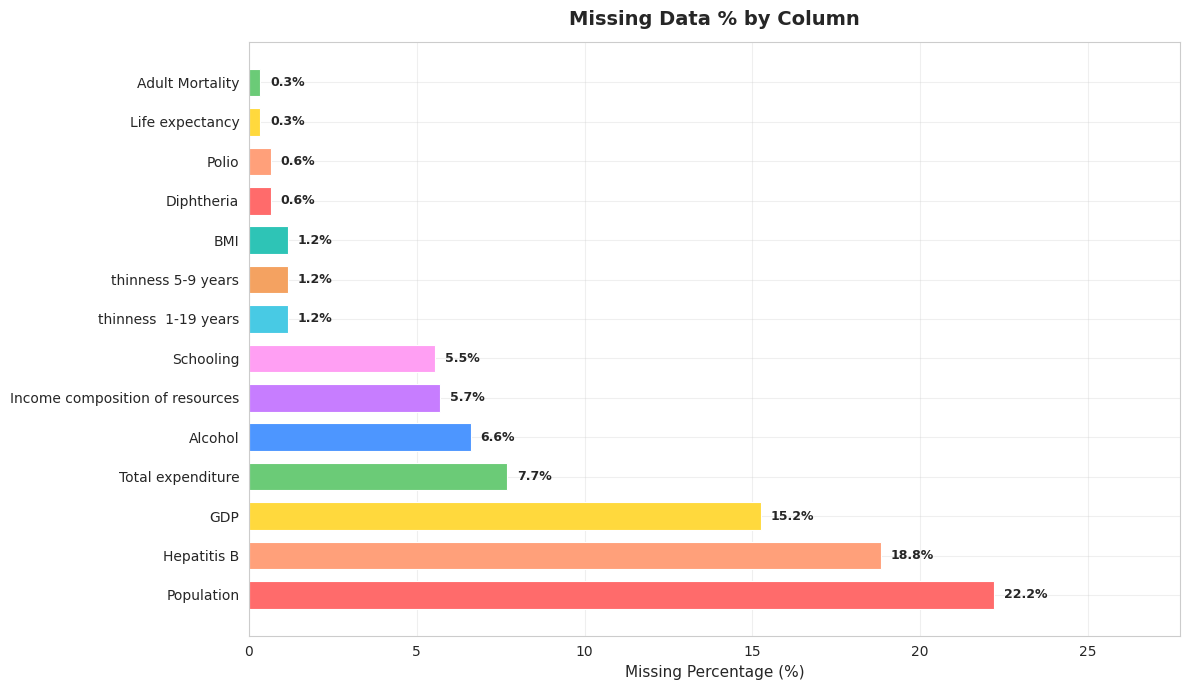

In [8]:
fig,ax=plt.subplots(figsize=(12,7))

missing_cols=df.isnull().mean().sort_values(ascending=False)
missing_cols=missing_cols[missing_cols>0]
colors_bar=[PALETTE[i%len(PALETTE)] for i in range(len(missing_cols))]
bars=ax.barh(range(len(missing_cols)),missing_cols.values*100,
             color=colors_bar,edgecolor='white',linewidth=0.8,height=0.7)
ax.set_yticks(range(len(missing_cols)))
ax.set_yticklabels(missing_cols.index,fontsize=10)
ax.set_xlabel('Missing Percentage (%)',fontsize=11)
ax.set_title('Missing Data % by Column',pad=12,fontsize=14,fontweight='bold')
ax.set_xlim(0,missing_cols.values.max()*100*1.25)
for i,(bar,v) in enumerate(zip(bars,missing_cols.values*100)):
    ax.text(v+0.3,i,f'{v:.1f}%',va='center',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()


### Missing Data Bar Chart

**Pattern**
- Population is the most data-deficient column at approximately 22% missing, followed by Hepatitis B (~19%) and GDP (~15%).
- Most columns have under 10% missing — a manageable proportion that can be imputed without major bias.

**Impact**
- This diagnosis directly informs the Week 3 imputation strategy, where skewed columns receive median imputation and symmetric columns receive mean imputation.


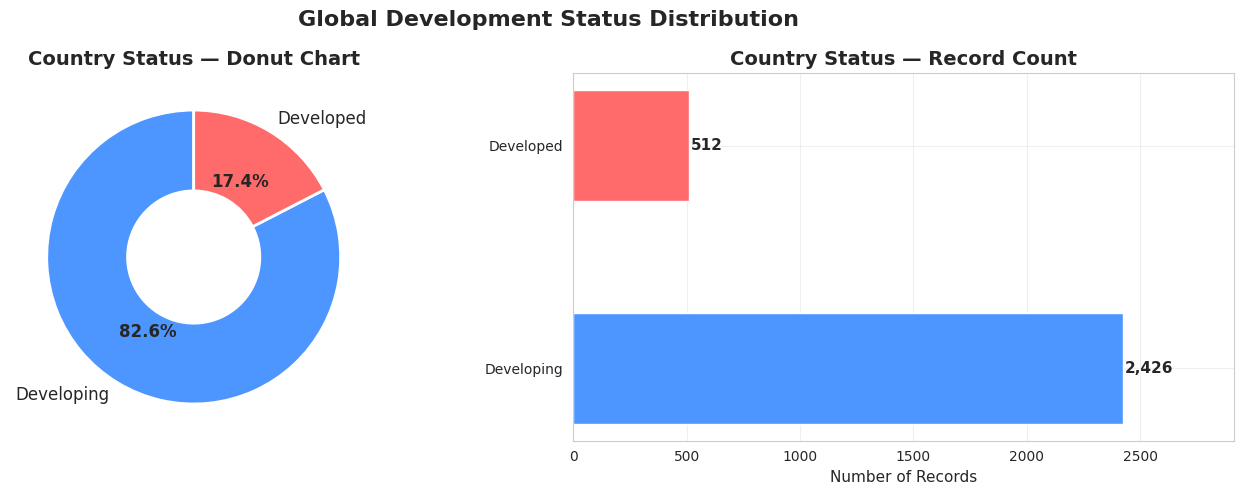

In [9]:
status_counts=df['Status'].value_counts()

fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Global Development Status Distribution',fontsize=16,fontweight='bold')

wedges,texts,autotexts=axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=['#4D96FF','#FF6B6B'],
    startangle=90,
    wedgeprops=dict(width=0.55,edgecolor='white',linewidth=2),
    textprops={'fontsize':12}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Country Status — Donut Chart')

bars=axes[1].barh(status_counts.index,status_counts.values,
                  color=['#4D96FF','#FF6B6B'],edgecolor='white',height=0.5)
for bar,val in zip(bars,status_counts.values):
    axes[1].text(bar.get_width()+5,bar.get_y()+bar.get_height()/2,
                 f'{val:,}',va='center',fontsize=11,fontweight='bold')
axes[1].set_xlabel('Number of Records')
axes[1].set_title('Country Status — Record Count')
axes[1].set_xlim(0,status_counts.max()*1.2)

plt.tight_layout()
plt.show()


### Development Status Distribution

**Class Imbalance**
- The dataset is heavily skewed toward **Developing countries** (~82% of all records), which mirrors real-world global demographics.

**Implications**
- When comparing health outcomes between Developed and Developing nations, this imbalance must be considered to avoid overgeneralising from the minority Developed group.
- This imbalance will be revisited during feature engineering in Week 6.


---
## Week 3 — The Cleaning Sprint | Data Preprocessing & Outlier Detection

**Objective:** Handle missing values intelligently, detect outliers using the IQR method, and produce a clean, stable dataset.

### Why Cleaning is Necessary

- Raw data is rarely analysis-ready; missing values introduce bias and extreme outliers distort statistical measures.
- A robust cleaning pipeline ensures every subsequent insight is based on representative, reliable data rather than artefacts of poor recording.

### Missing Value Strategy

| Distribution Shape | Imputation Method | Reason |
|---|---|---|
| Highly Skewed (skew > 1) | **Median** | Robust to extreme values; preserves the centre |
| Approximately Symmetric | **Mean** | Preserves the overall average |
| Categorical | **Mode** | Most frequent value is the best representative |

### Outlier Detection — IQR Method

- **Q1** = 25th percentile, **Q3** = 75th percentile
- **IQR** = Q3 − Q1
- **Outlier boundaries:** Lower = Q1 − 1.5 × IQR, Upper = Q3 + 1.5 × IQR
- Values outside these bounds are flagged as statistical outliers


In [10]:
df_before_week3=df.copy()

num_cols=df.select_dtypes(include=np.number).columns.tolist()
cat_cols=df.select_dtypes(include='object').columns.tolist()

print(f"Snapshot saved as df_before_week3")
print(f"\nNumerical Columns ({len(num_cols)}):")
print(', '.join(num_cols))
print(f"\nCategorical Columns ({len(cat_cols)}):")
print(', '.join(cat_cols))


Snapshot saved as df_before_week3

Numerical Columns (20):
Year, Life expectancy, Adult Mortality, infant deaths, Alcohol, percentage expenditure, Hepatitis B, Measles, BMI, under-five deaths, Polio, Total expenditure, Diphtheria, HIV/AIDS, GDP, Population, thinness  1-19 years, thinness 5-9 years, Income composition of resources, Schooling

Categorical Columns (2):
Country, Status


A frozen snapshot `df_before_week3` is created before any modifications. This is essential for producing before-and-after comparisons later. Separating numerical and categorical columns ensures each group receives the correct imputation treatment.


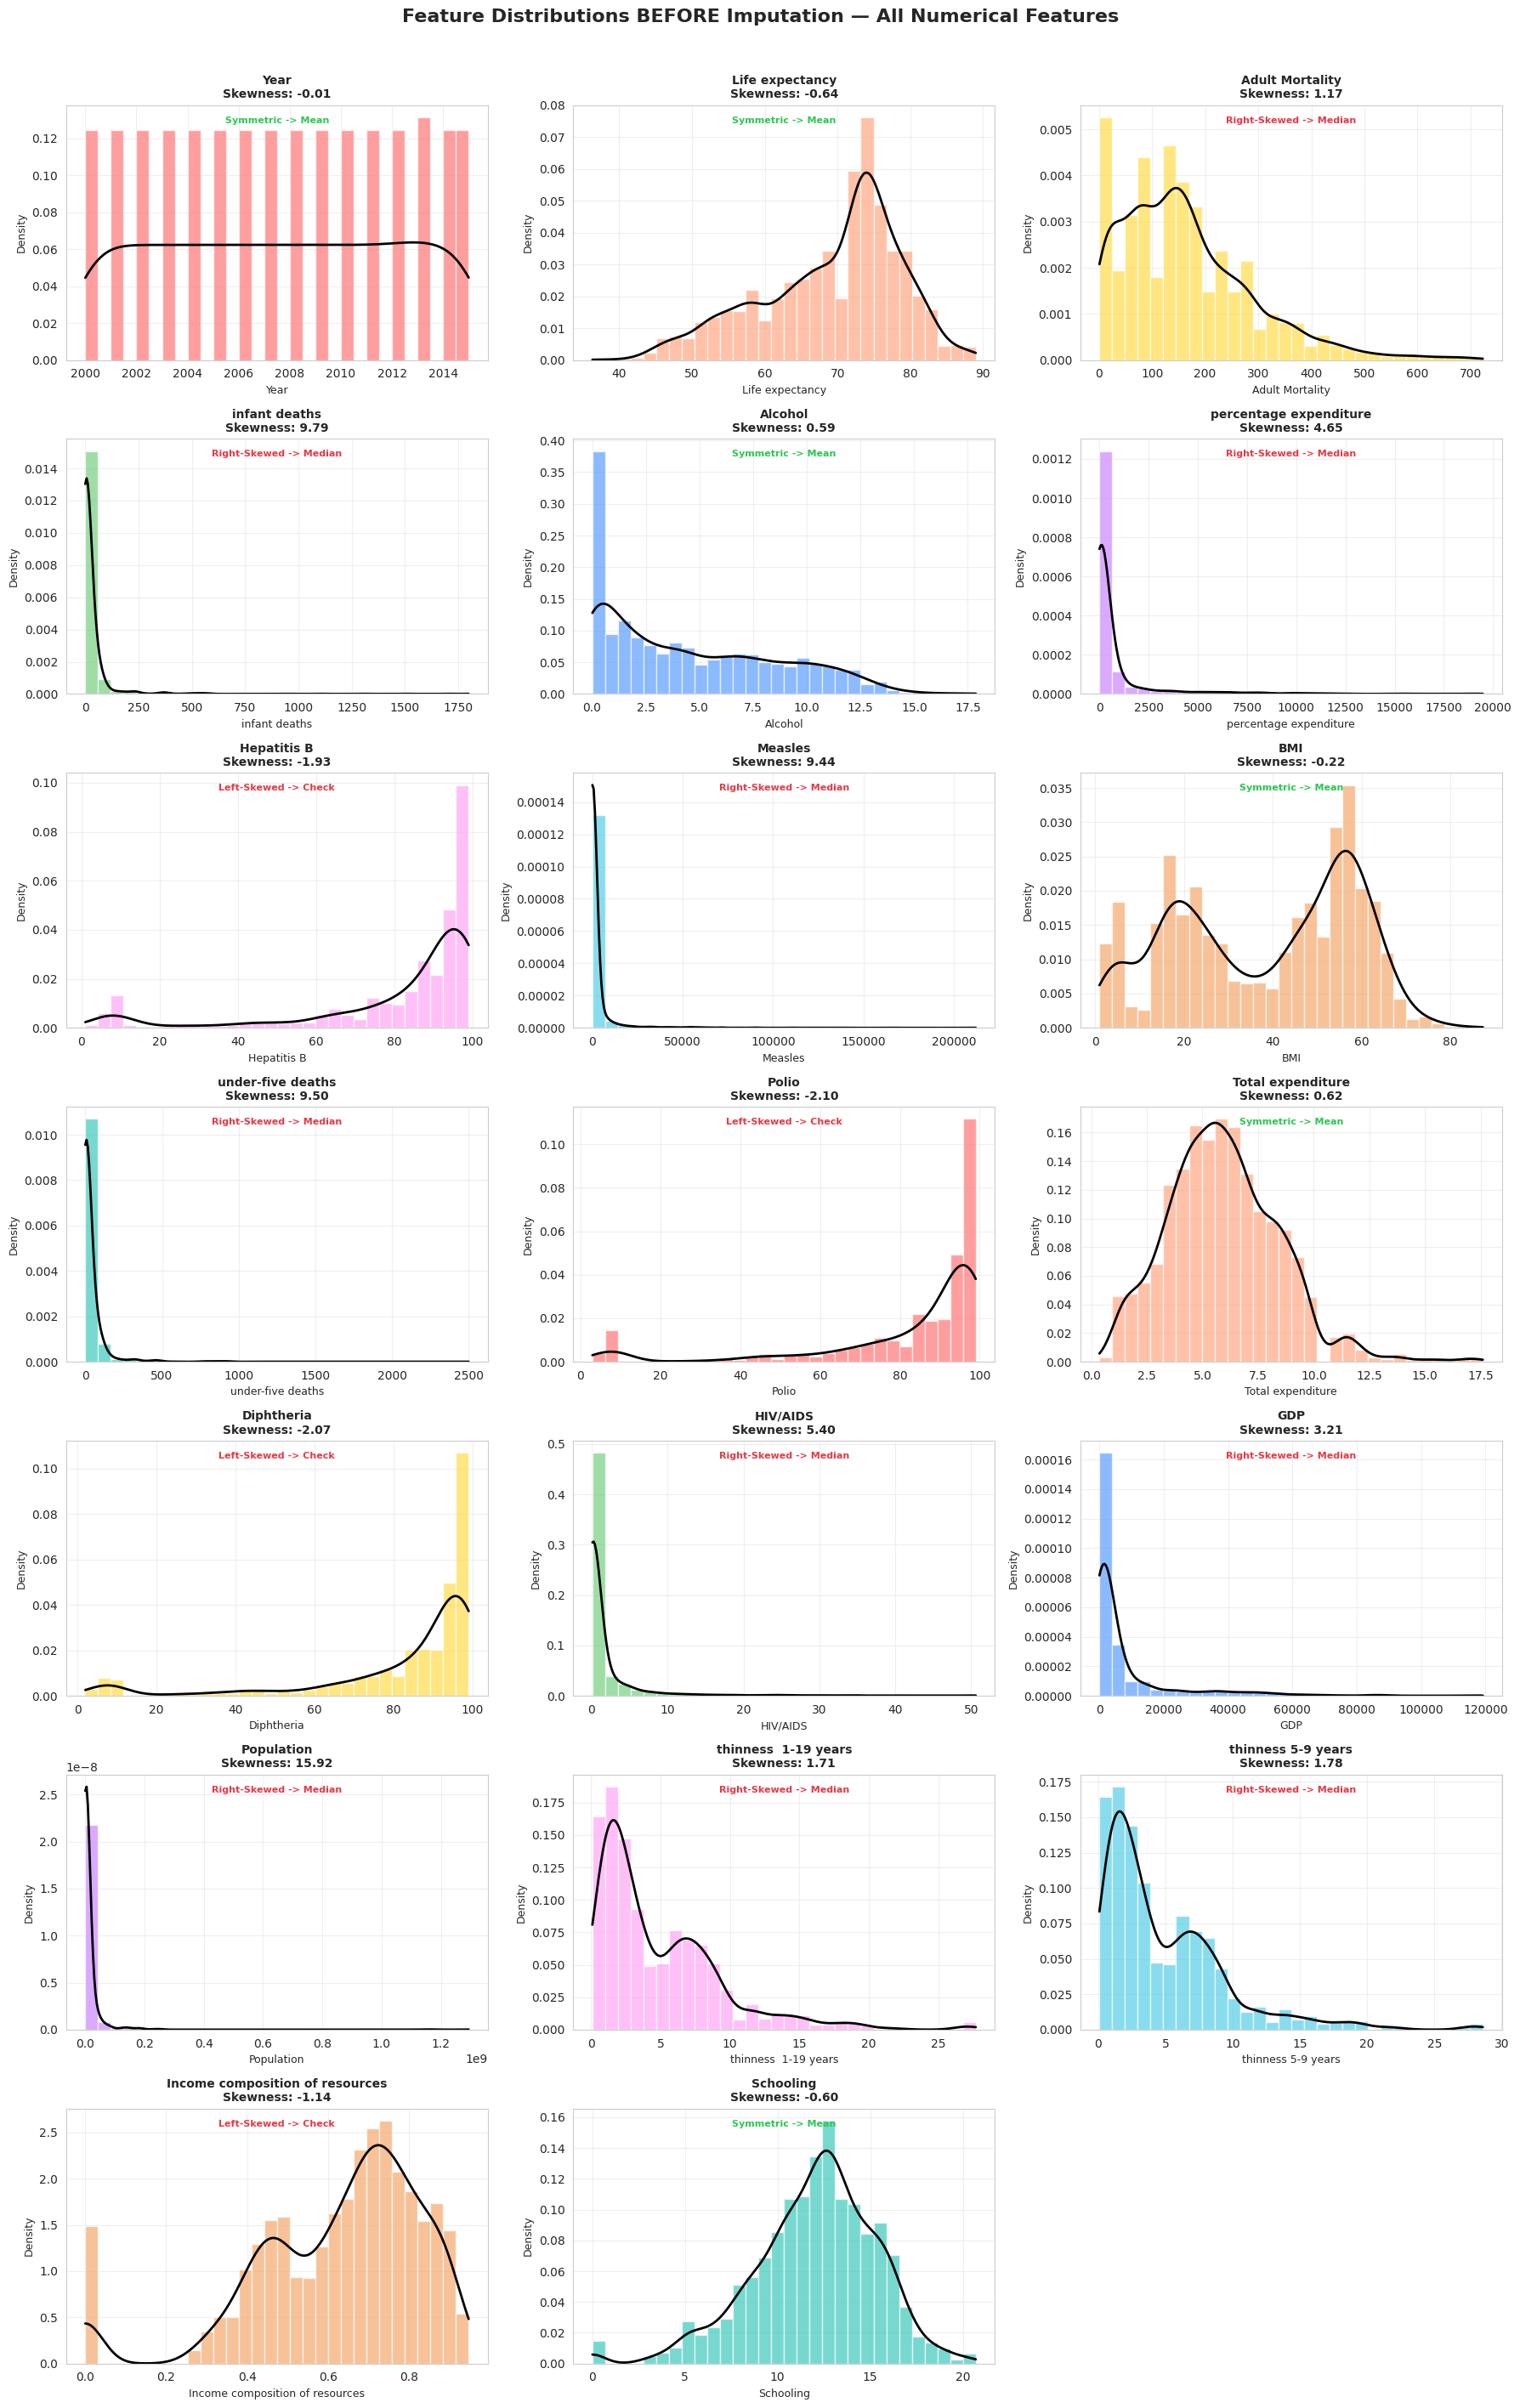

In [11]:
n_cols_plot=len(num_cols)
ncols=3
nrows=(n_cols_plot+ncols-1)//ncols

fig,axes=plt.subplots(nrows,ncols,figsize=(18,nrows*4))
fig.suptitle('Feature Distributions BEFORE Imputation — All Numerical Features',
             fontsize=16,fontweight='bold',y=1.01)
axes_flat=axes.flatten()

for i,col in enumerate(num_cols):
    ax=axes_flat[i]
    color=PALETTE[i%len(PALETTE)]
    data=df_before_week3[col].dropna()
    ax.hist(data,bins=30,color=color,alpha=0.65,edgecolor='white',density=True)
    try:
        kde=gaussian_kde(data)
        xr=np.linspace(data.min(),data.max(),300)
        ax.plot(xr,kde(xr),color='black',lw=2)
    except Exception:
        pass
    skew_val=data.skew()
    ax.set_title(f'{col}\nSkewness: {skew_val:.2f}',fontweight='bold',fontsize=10)
    ax.set_xlabel(col,fontsize=9)
    ax.set_ylabel('Density',fontsize=9)
    tag='Right-Skewed -> Median' if skew_val>1 else ('Left-Skewed -> Check' if skew_val<-1 else 'Symmetric -> Mean')
    tcol='#E63946' if abs(skew_val)>1 else '#2DC653'
    ax.annotate(tag,xy=(0.5,0.93),xycoords='axes fraction',ha='center',
                fontsize=8,color=tcol,fontweight='bold')

for j in range(n_cols_plot,len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()


### Pre-Imputation Distributions

**Highly Skewed (Median imputation)**
- GDP, Population, Measles, and HIV/AIDS show extreme right-skew with long upper tails.
- These features will receive median imputation to avoid being pulled by extreme values.

**Approximately Symmetric (Mean imputation)**
- Life Expectancy, Schooling, and BMI are relatively symmetric.
- Mean imputation is appropriate for these features.

**Borderline Features**
- Alcohol and Total Expenditure are mildly skewed; median imputation is applied as a conservative choice.
- The skewness annotations on each plot directly guide the imputation code that follows.


In [12]:
missing_before=df.isnull().sum()
log=[]

for col in num_cols:
    skew=df[col].skew()
    if skew>1:
        df[col]=df[col].fillna(df[col].median())
        log.append((col,round(skew,2),'MEDIAN'))
    else:
        df[col]=df[col].fillna(df[col].mean())
        log.append((col,round(skew,2),'MEAN'))

for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

missing_after=df.isnull().sum()

log_df=pd.DataFrame(log,columns=['Column','Skewness','Method Used'])
print("="*55)
print("IMPUTATION LOG")
print("="*55)
display(log_df)

print(f"\nMissing cells before imputation : {missing_before.sum()}")
print(f"Missing cells after  imputation : {missing_after.sum()}")


IMPUTATION LOG


,Column,Skewness,Method Used
0,Year,-0.01,MEAN
1,Life expectancy,-0.64,MEAN
2,Adult Mortality,1.17,MEDIAN
3,infant deaths,9.79,MEDIAN
4,Alcohol,0.59,MEAN
5,percentage expenditure,4.65,MEDIAN
6,Hepatitis B,-1.93,MEAN
7,Measles,9.44,MEDIAN
8,BMI,-0.22,MEAN
9,under-five deaths,9.50,MEDIAN



Missing cells before imputation : 2563
Missing cells after  imputation : 0


The imputation loop examines skewness for every numerical column and applies the appropriate strategy. The log provides full transparency about which method was used and why. After this step, all missing values are eliminated — confirmed by the zero count. The categorical column 'Status' was filled with its mode (Developing).


In [13]:
outlier_data=[]
for col in num_cols:
    Q1,Q3=df[col].quantile(0.25),df[col].quantile(0.75)
    IQR=Q3-Q1
    lower,upper=Q1-1.5*IQR,Q3+1.5*IQR
    count=((df[col]<lower)|(df[col]>upper)).sum()
    pct=count/len(df)*100
    outlier_data.append({'Feature':col,'Outlier Count':count,
                         'Outlier %':round(pct,2),
                         'Lower Fence':round(lower,3),
                         'Upper Fence':round(upper,3)})

outlier_df=pd.DataFrame(outlier_data).sort_values('Outlier %',ascending=False)
display(outlier_df)


,Feature,Outlier Count,Outlier %,Lower Fence,Upper Fence
13,HIV/AIDS,542,18.45,-0.950,1.850000e+00
7,Measles,542,18.45,-540.375,9.006250e+02
15,Population,452,15.38,-5829263.750,1.083255e+07
14,GDP,445,15.15,-5717.890,1.107778e+04
9,under-five deaths,394,13.41,-42.000,7.000000e+01
5,percentage expenditure,389,13.24,-650.588,1.096807e+03
6,Hepatitis B,316,10.76,58.351,1.185890e+02
3,infant deaths,315,10.72,-33.000,5.500000e+01
12,Diphtheria,298,10.14,49.500,1.255000e+02
10,Polio,279,9.50,49.500,1.255000e+02


### IQR Outlier Report

**Why IQR?**
- The IQR method is distribution-agnostic — it does not assume normally distributed data, making it ideal for socioeconomic datasets like WHO data which are inherently skewed.

**Findings**
- **Population, Infant Deaths, Measles, and HIV/AIDS** have the highest outlier percentages.
- This is consistent with extreme inequality between nations (e.g., China vs. Tuvalu in population; Sub-Saharan Africa vs. Europe in HIV/AIDS).
- Deleting these rows would remove legitimate data from both the world's most populous and smallest nations, so capping is the preferred approach.


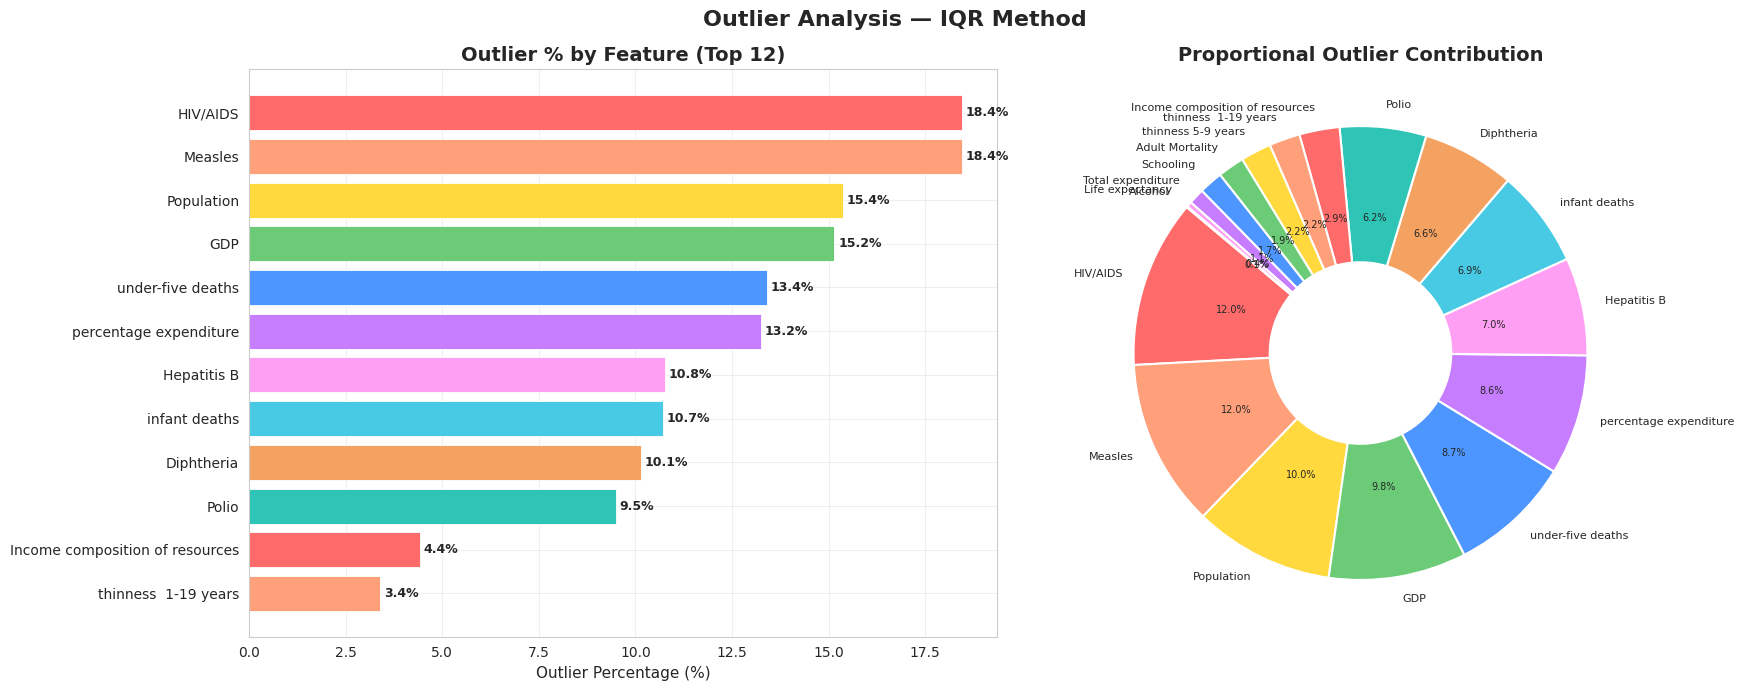

In [14]:
fig,axes=plt.subplots(1,2,figsize=(18,7))
fig.suptitle('Outlier Analysis — IQR Method',fontsize=16,fontweight='bold')

top_outlier=outlier_df.head(12)
colors_o=[PALETTE[i%len(PALETTE)] for i in range(len(top_outlier))]
bars=axes[0].barh(top_outlier['Feature'],top_outlier['Outlier %'],
                  color=colors_o,edgecolor='white',linewidth=0.6)
axes[0].set_xlabel('Outlier Percentage (%)')
axes[0].set_title('Outlier % by Feature (Top 12)',fontweight='bold')
axes[0].invert_yaxis()
for bar,val in zip(bars,top_outlier['Outlier %']):
    axes[0].text(bar.get_width()+0.1,bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%',va='center',fontsize=9,fontweight='bold')

wedge_data=outlier_df[outlier_df['Outlier Count']>0]
wedges,texts,autotexts=axes[1].pie(
    wedge_data['Outlier Count'],
    labels=wedge_data['Feature'],
    autopct='%1.1f%%',
    colors=[PALETTE[i%len(PALETTE)] for i in range(len(wedge_data))],
    startangle=140,
    wedgeprops=dict(width=0.6,edgecolor='white',linewidth=1.5),
    textprops={'fontsize':8}
)
for at in autotexts:
    at.set_fontsize(7)
axes[1].set_title('Proportional Outlier Contribution',fontweight='bold')

plt.tight_layout()
plt.show()


### Outlier Distribution

**Bar Chart**
- Population, Infant Deaths, and Measles have the highest outlier percentages, driven by nations with vastly different demographic scales.

**Donut Chart**
- Just 3–4 features account for the majority of all outliers, confirming that targeted capping rather than global truncation is the right approach.

**Strategy**
- IQR capping will be applied: values below Q1 − 1.5×IQR are clipped to the lower fence, values above Q3 + 1.5×IQR are clipped to the upper fence. All records are preserved.


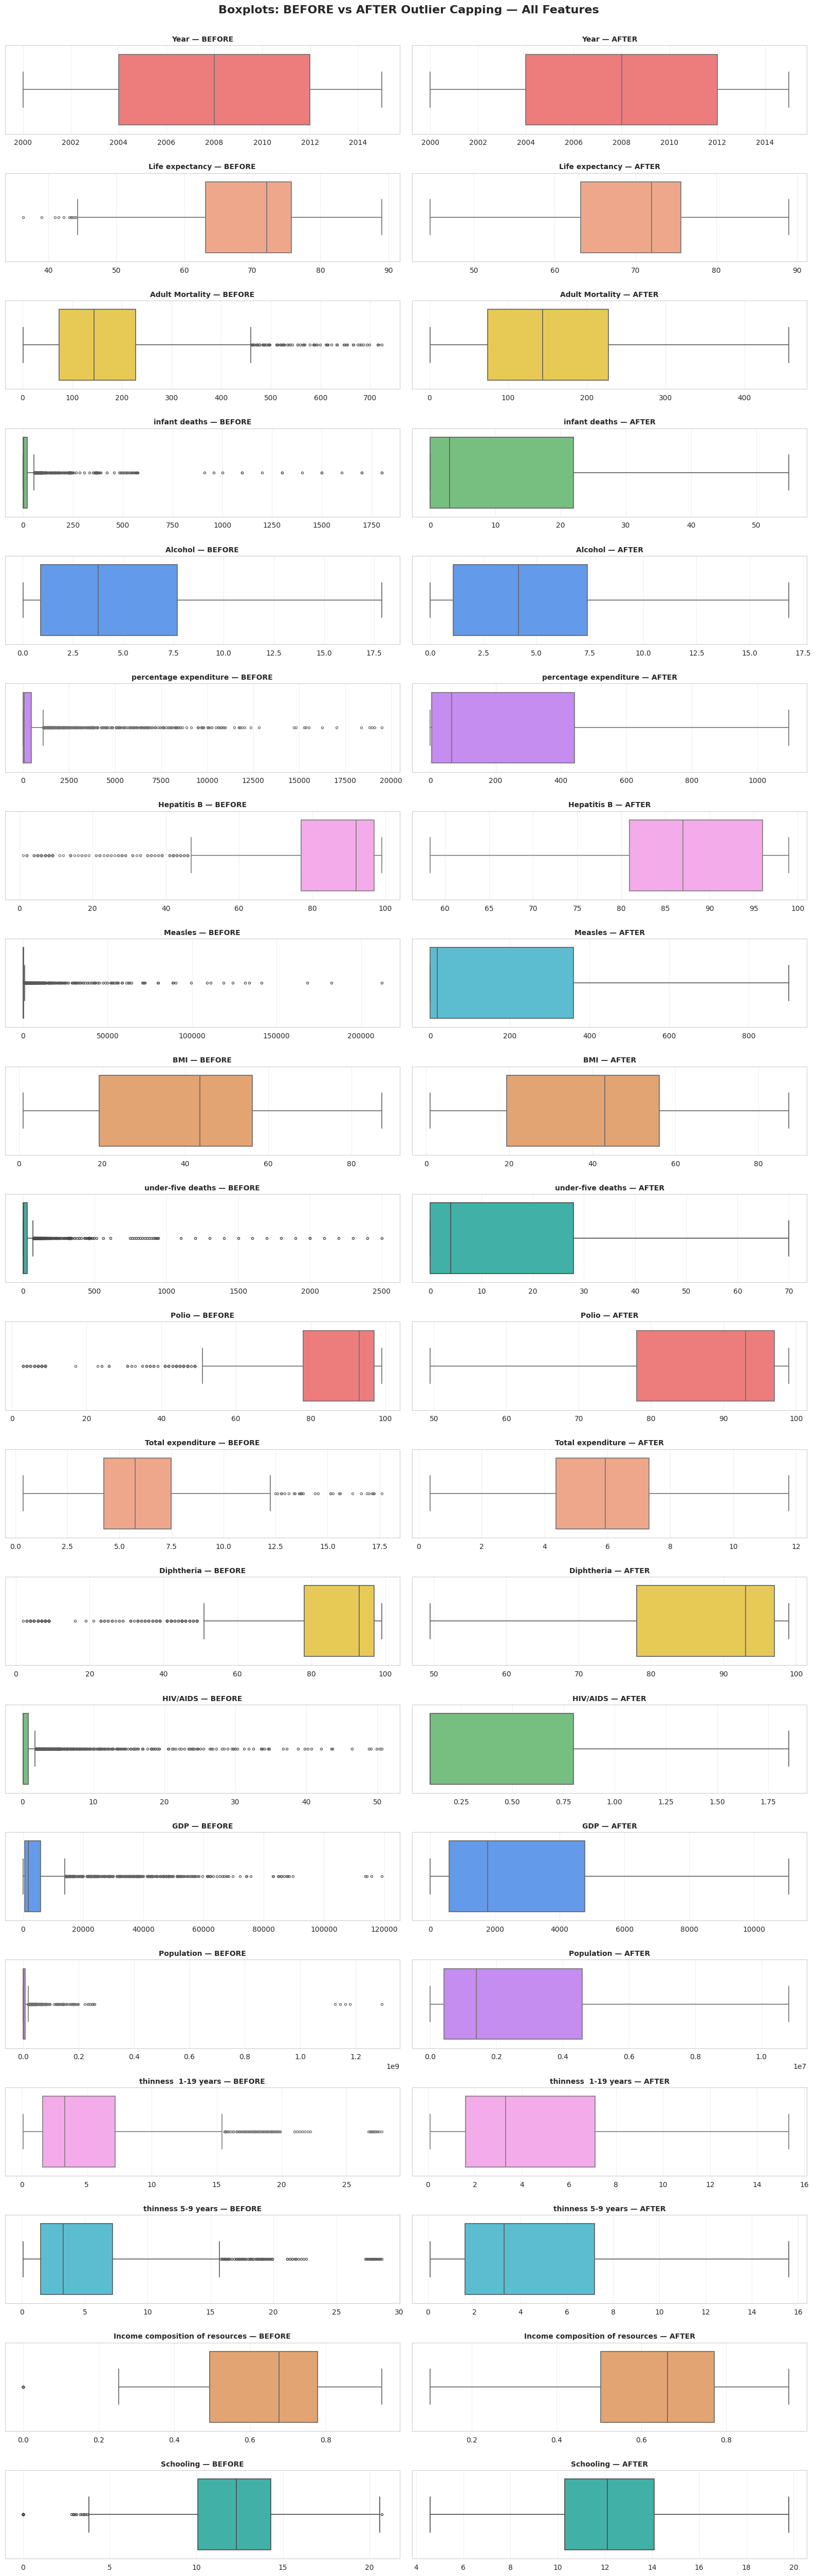

IQR Capping applied — df_after_week3 is clean and ready


In [15]:
df_after_week3=df.copy()
for col in num_cols:
    Q1,Q3=df_after_week3[col].quantile(0.25),df_after_week3[col].quantile(0.75)
    IQR=Q3-Q1
    df_after_week3[col]=np.clip(df_after_week3[col],Q1-1.5*IQR,Q3+1.5*IQR)

n=len(num_cols)
fig,axes=plt.subplots(n,2,figsize=(16,n*2.5))
fig.suptitle('Boxplots: BEFORE vs AFTER Outlier Capping — All Features',
             fontsize=16,fontweight='bold',y=1.002)

for i,col in enumerate(num_cols):
    c=PALETTE[i%len(PALETTE)]
    sns.boxplot(x=df_before_week3[col],ax=axes[i][0],
                color=c,linewidth=1.2,flierprops={'marker':'o','markersize':3})
    axes[i][0].set_title(f'{col} — BEFORE',fontsize=10)
    axes[i][0].set_xlabel('')

    sns.boxplot(x=df_after_week3[col],ax=axes[i][1],
                color=c,linewidth=1.2,flierprops={'marker':'o','markersize':3})
    axes[i][1].set_title(f'{col} — AFTER',fontsize=10)
    axes[i][1].set_xlabel('')

plt.tight_layout()
plt.show()
print("IQR Capping applied — df_after_week3 is clean and ready")


### Before vs. After Capping

**Effect on Distributions**
- Before capping, long whiskers and numerous flier dots indicate extreme values distorting the IQR.
- After capping, whiskers are compact and stray dots are removed.

**Central Tendency Preserved**
- The median line remains in the same position after capping, confirming that central tendency is preserved while extremes are controlled.

**No Data Loss**
- All 2,938 rows are preserved — capping bounds extreme values without deleting any records.


In [16]:
df_after_week3.to_csv("life_expectancy_cleaned.csv",index=False)

print("="*60)
print("DATASET EXPORTED -> life_expectancy_cleaned.csv")
print("="*60)
print(f"  Shape              : {df_after_week3.shape}")
print(f"  Remaining Nulls    : {df_after_week3.isnull().sum().sum()}")
print("\nDescriptive Stats — Key Columns (Before vs After):")
cols_show=['Life expectancy','GDP','Adult Mortality','Population']
comp=pd.concat([
    df_before_week3[cols_show].describe().T[['mean','std']].rename(columns={'mean':'Mean_Before','std':'Std_Before'}),
    df_after_week3[cols_show].describe().T[['mean','std']].rename(columns={'mean':'Mean_After','std':'Std_After'})
],axis=1)
display(comp)


DATASET EXPORTED -> life_expectancy_cleaned.csv
  Shape              : (2938, 22)
  Remaining Nulls    : 0

Descriptive Stats — Key Columns (Before vs After):


,Mean_Before,Std_Before,Mean_After,Std_After
Life expectancy,6.922493e+01,9.523867e+00,6.923480e+01,9.479612e+00
GDP,7.483158e+03,1.427017e+04,3.443020e+03,3.777902e+03
Adult Mortality,1.647964e+02,1.242921e+02,1.619534e+02,1.154885e+02
Population,1.275338e+07,6.101210e+07,3.173255e+06,3.837555e+06


The comparison confirms that standard deviations decreased for high-variance features — the expected signature of successful outlier capping. Means shifted slightly for extremely skewed columns (Population, GDP) as upper extremes were bounded. The dataset size is unchanged; the cleaned CSV is now the input for all subsequent analyses.


---
## Week 4 — EDA Deep Dive | Univariate, Bivariate & Multivariate Analysis

**Objective:** Extract meaningful patterns, relationships, and anomalies through systematic statistical exploration.

### EDA Framework

| Analysis Type | Question Answered | Techniques |
|---|---|---|
| **Univariate** | What does each variable look like individually? | Histograms, KDE, Boxplots, Violin, CDF |
| **Bivariate** | How do two variables relate? | Scatter, Regression, Bar, Line, Strip |
| **Multivariate** | How do multiple variables interact? | Heatmap, 3D Scatter, Pair Plot |
| **Time Series** | How have indicators changed over 2000–2015? | Line plots, Trend analysis |
| **Geographic** | Which countries lead/lag on health outcomes? | Ranked bar charts |


In [17]:
df=pd.read_csv("life_expectancy_cleaned.csv")
df.columns=df.columns.str.strip()
print(f"Cleaned dataset loaded | Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Cleaned dataset loaded | Shape: (2938, 22)
Columns: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


---
### Univariate Analysis

**What is Univariate Analysis?**

Univariate analysis examines each variable in isolation to understand its individual distribution, central tendency, spread, and shape. It is the foundational step of any EDA before relationships between variables are explored.

**Why it Matters**
- Reveals whether a variable is symmetric or skewed, which informs imputation and transformation choices.
- Identifies the range and typical values (mean, median, IQR) of each feature.
- Detects outliers at the single-variable level.
- Provides a baseline understanding of each feature before bivariate comparisons are introduced.

**Methods Used**

- **Histogram + KDE** — Shows the probability density of a continuous variable and the shape of its distribution.
- **Boxplot** — Displays the median, IQR, whiskers, and outlier points for spread analysis.
- **Violin Plot** — Combines a boxplot with a KDE to show the full distribution shape by group.
- **CDF (Cumulative Distribution Function)** — Shows what proportion of data falls below each value, useful for understanding percentile thresholds.


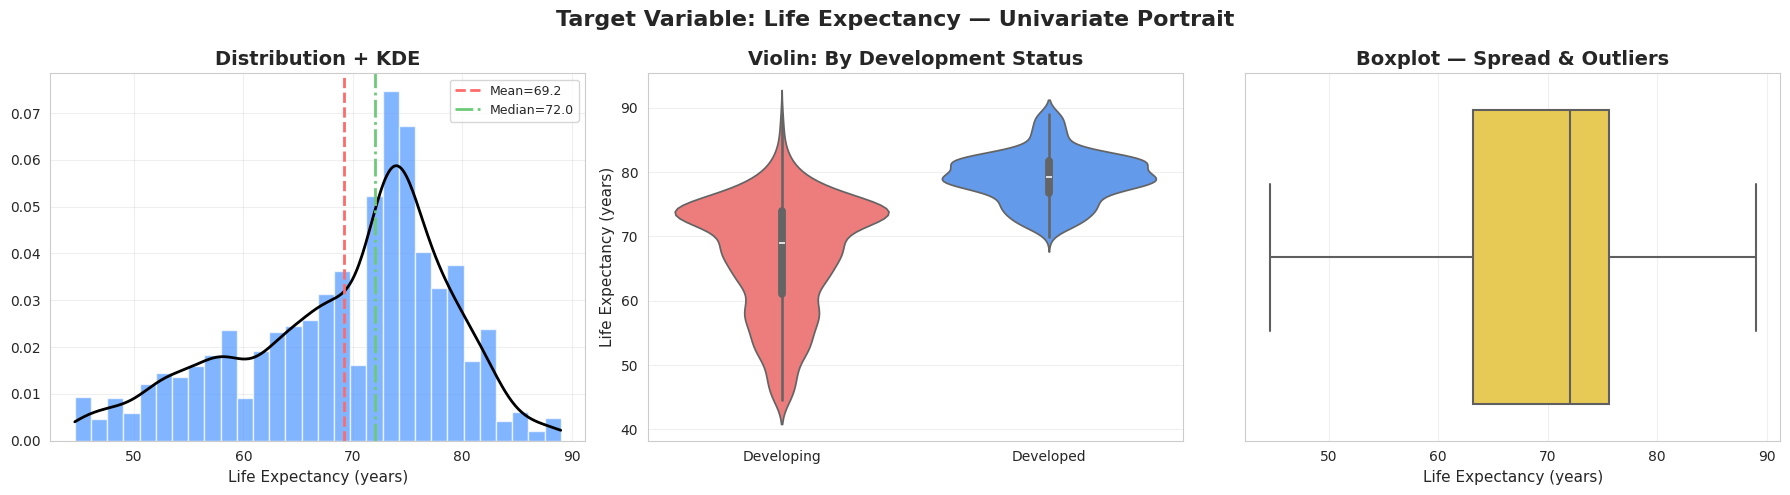

In [18]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Target Variable: Life Expectancy — Univariate Portrait',
             fontsize=16,fontweight='bold')

axes[0].hist(df['Life expectancy'],bins=30,color='#4D96FF',
             alpha=0.7,edgecolor='white',density=True)
d=df['Life expectancy'].dropna()
kde=gaussian_kde(d)
x=np.linspace(d.min(),d.max(),300)
axes[0].plot(x,kde(x),'k-',lw=2)
axes[0].axvline(d.mean(),color='#FF6B6B',lw=2,linestyle='--',label=f"Mean={d.mean():.1f}")
axes[0].axvline(d.median(),color='#6BCB77',lw=2,linestyle='-.',label=f"Median={d.median():.1f}")
axes[0].set_title('Distribution + KDE')
axes[0].legend(fontsize=9)
axes[0].set_xlabel('Life Expectancy (years)')

status_col=df['Status'] if df['Status'].dtype==object else df['Status'].map({0:'Developing',1:'Developed'})
temp=df.copy();temp['Status_Label']=status_col
sns.violinplot(x='Status_Label',y='Life expectancy',data=temp,
               palette=['#FF6B6B','#4D96FF'],inner='box',ax=axes[1])
axes[1].set_title('Violin: By Development Status')
axes[1].set_xlabel('')
axes[1].set_ylabel('Life Expectancy (years)')

sns.boxplot(x=df['Life expectancy'],color='#FFD93D',
            linewidth=1.5,ax=axes[2],
            flierprops={'marker':'o','markerfacecolor':'#FF6B6B','markersize':4})
axes[2].set_title('Boxplot — Spread & Outliers')
axes[2].set_xlabel('Life Expectancy (years)')

plt.tight_layout()
plt.show()


### Life Expectancy Distribution

**Distribution Shape**
- The distribution is left-skewed with a bimodal tendency — most countries cluster near 70–75 years, but a secondary peak near 55–60 years reflects a distinct group of low-income nations.

**Development Gap**
- The violin plot shows a pronounced gap between **Developed** (median ~80 years) and **Developing** (median ~68 years) nations — approximately a 12-year health inequality gap.

**Spread**
- The boxplot confirms the IQR spans roughly 62–75 years, with lower outliers representing nations with extreme mortality burdens.


---
#### Section 1 — Core Feature Distributions

The following histograms examine the distribution shapes of the six most important continuous features: Life Expectancy, GDP, Schooling, Adult Mortality, BMI, and Alcohol Consumption. Each plot includes a KDE overlay, mean and median reference lines, and a skewness label to guide transformation decisions.


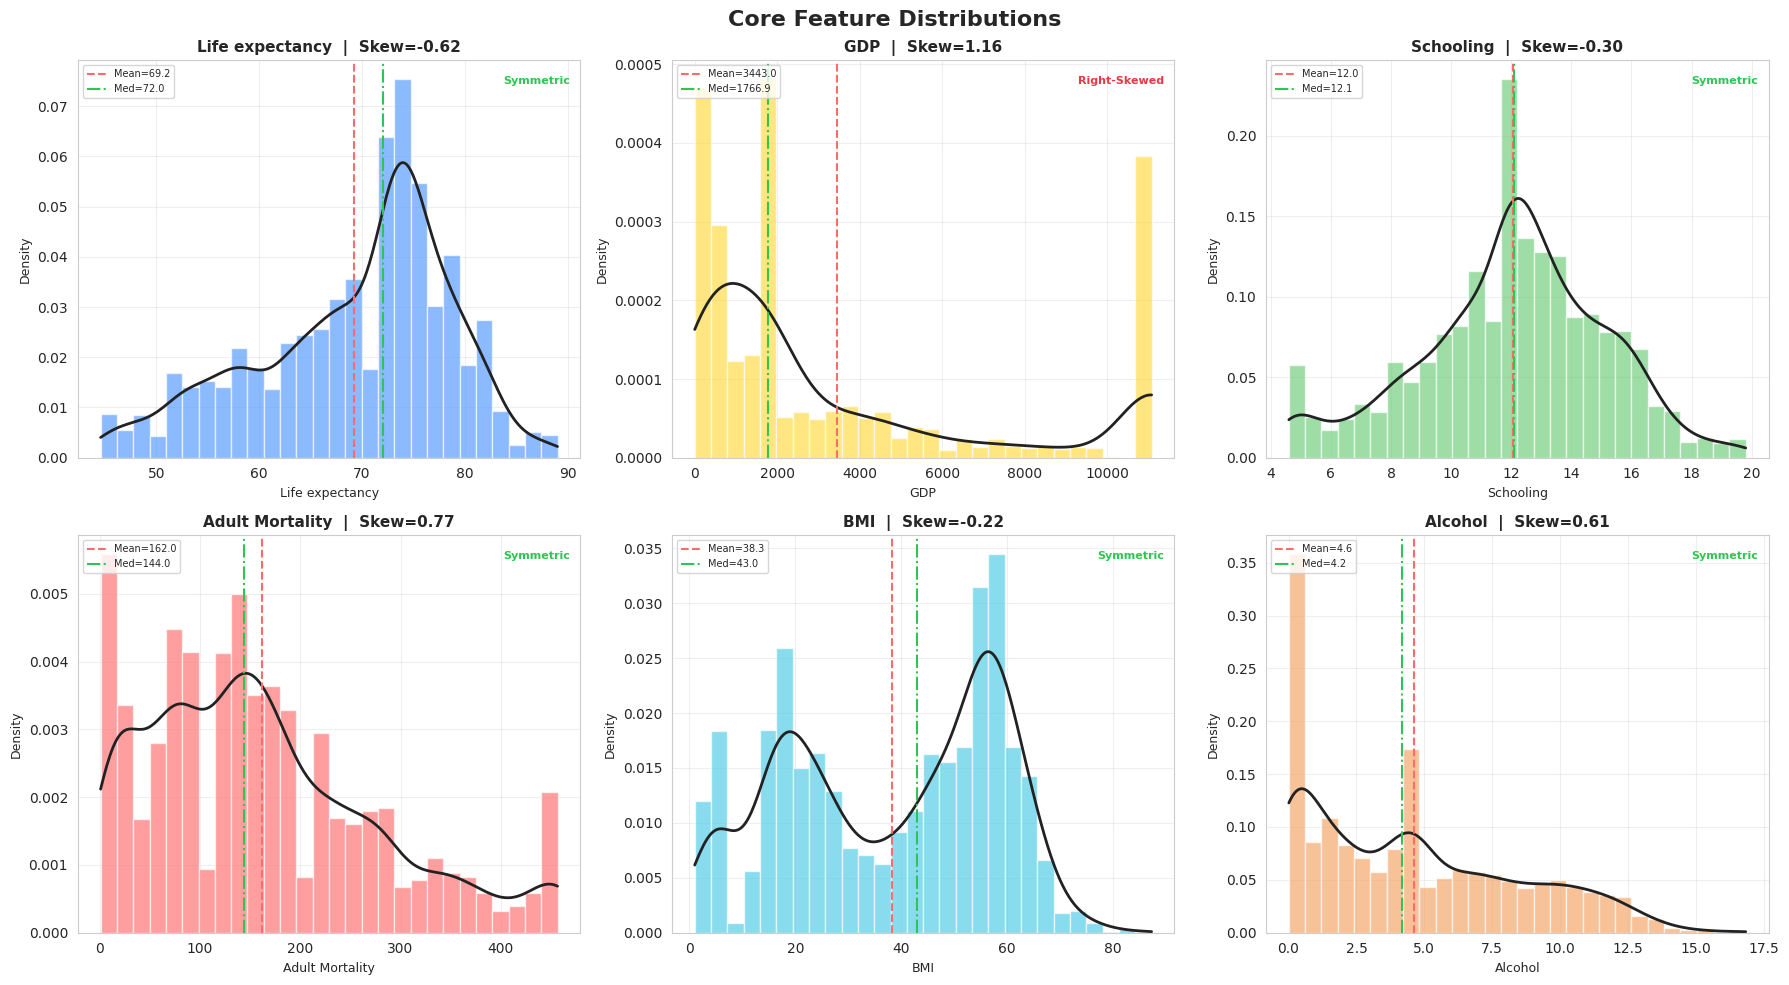

In [49]:
core_feats=['Life expectancy','GDP','Schooling','Adult Mortality','BMI','Alcohol']
core_colors=['#4D96FF','#FFD93D','#6BCB77','#FF6B6B','#48CAE4','#F4A261']

fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle('Core Feature Distributions',fontsize=16,fontweight='bold')
axes_flat=axes.flatten()

for i,col in enumerate(core_feats):
    ax=axes_flat[i]
    c=core_colors[i]
    data=df[col].dropna()
    ax.hist(data,bins=28,color=c,alpha=0.65,edgecolor='white',density=True)
    try:
        kde=gaussian_kde(data)
        xr=np.linspace(data.min(),data.max(),300)
        ax.plot(xr,kde(xr),color='#222222',lw=2)
    except Exception:
        pass
    skew_val=data.skew()
    ax.axvline(data.mean(),color='#FF6B6B',lw=1.5,linestyle='--',label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(),color='#2DC653',lw=1.5,linestyle='-.',label=f'Med={data.median():.1f}')
    ax.set_title(f'{col}  |  Skew={skew_val:.2f}',fontweight='bold',fontsize=11)
    ax.set_xlabel(col,fontsize=9)
    ax.set_ylabel('Density',fontsize=9)
    tag='Right-Skewed' if skew_val>1 else ('Left-Skewed' if skew_val<-1 else 'Symmetric')
    color_tag='#E63946' if abs(skew_val)>1 else '#2DC653'
    ax.text(0.98,0.94,tag,transform=ax.transAxes,ha='right',
            fontsize=8,color=color_tag,fontweight='bold')
    ax.legend(fontsize=7,loc='upper left')

plt.tight_layout()
plt.show()


### Core Feature Distributions

**Life Expectancy**
- Near-symmetric with slight left skew, centered around 69 years globally.

**GDP**
- Heavily right-skewed — a small number of wealthy nations dominate the upper tail while the majority cluster near zero on a linear scale.

**Schooling**
- Approximately symmetric, indicating relatively uniform global access to education, centered around 11–12 years.

**Adult Mortality**
- Right-skewed — most nations have moderate mortality rates, but a long tail reflects high-burden nations in Sub-Saharan Africa.

**BMI**
- Slightly left-skewed, with most countries clustered around 38–50 (population averages, not individual values).

**Alcohol**
- Right-skewed with a peak near low consumption and a tail representing high-consumption European nations.


---
#### Section 2 — Health Indicator Distributions

This section examines the distributions of key disease and immunisation variables. These features are critical for understanding child health outcomes and infectious disease burden across nations.


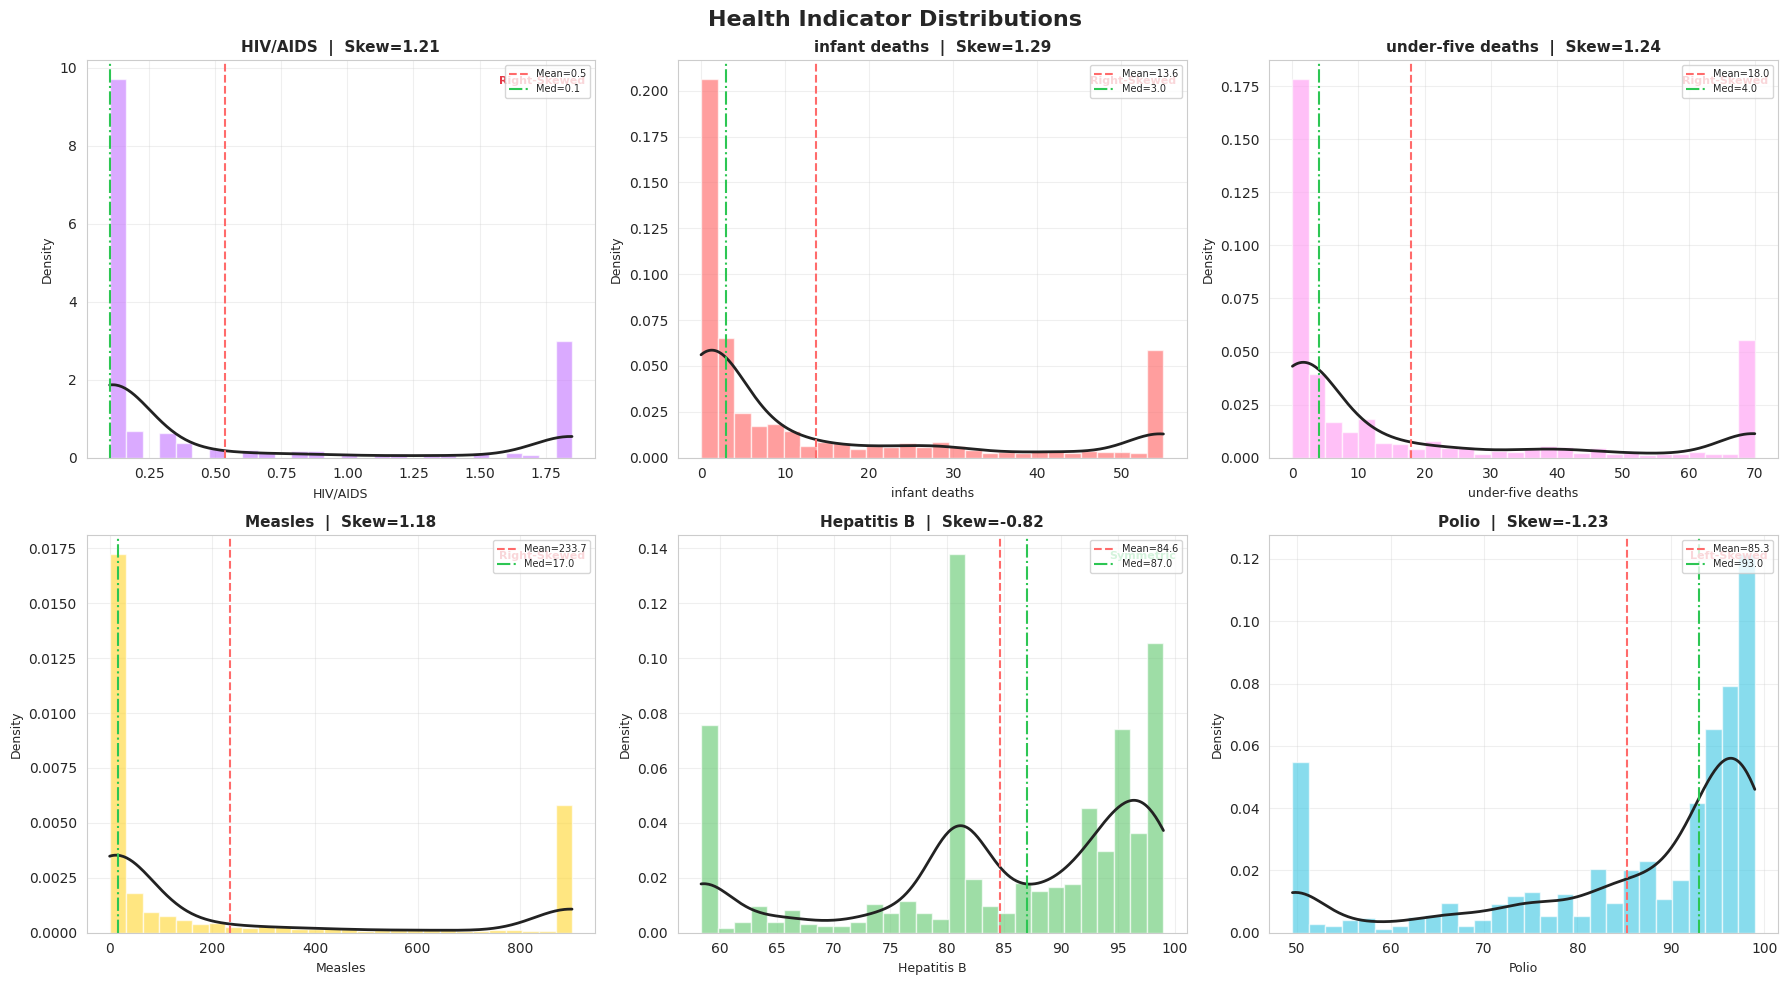

In [50]:
health_feats=['HIV/AIDS','infant deaths','under-five deaths','Measles','Hepatitis B','Polio']
health_colors=['#C77DFF','#FF6B6B','#FF9FF3','#FFD93D','#6BCB77','#48CAE4']

fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle('Health Indicator Distributions',fontsize=16,fontweight='bold')
axes_flat=axes.flatten()

for i,col in enumerate(health_feats):
    ax=axes_flat[i]
    c=health_colors[i]
    data=df[col].dropna()
    ax.hist(data,bins=28,color=c,alpha=0.65,edgecolor='white',density=True)
    try:
        kde=gaussian_kde(data)
        xr=np.linspace(data.min(),data.max(),300)
        ax.plot(xr,kde(xr),color='#222222',lw=2)
    except Exception:
        pass
    skew_val=data.skew()
    ax.axvline(data.mean(),color='#FF6B6B',lw=1.5,linestyle='--',label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(),color='#2DC653',lw=1.5,linestyle='-.',label=f'Med={data.median():.1f}')
    ax.set_title(f'{col}  |  Skew={skew_val:.2f}',fontweight='bold',fontsize=11)
    ax.set_xlabel(col,fontsize=9)
    ax.set_ylabel('Density',fontsize=9)
    tag='Right-Skewed' if skew_val>1 else ('Left-Skewed' if skew_val<-1 else 'Symmetric')
    color_tag='#E63946' if abs(skew_val)>1 else '#2DC653'
    ax.text(0.98,0.94,tag,transform=ax.transAxes,ha='right',
            fontsize=8,color=color_tag,fontweight='bold')
    ax.legend(fontsize=7,loc='upper right')

plt.tight_layout()
plt.show()


### Health Indicator Distributions

**HIV/AIDS**
- Extremely right-skewed — the vast majority of countries have very low prevalence, while a small number of Sub-Saharan African nations drive the upper tail.

**Infant Deaths & Under-Five Deaths**
- Both are strongly right-skewed and nearly identical in distribution, reflecting that infant mortality is the primary driver of under-five deaths. These two columns are near-collinear and one may be dropped during feature engineering.

**Measles**
- Right-skewed, reflecting that most countries have high vaccination coverage and low case counts, while a few outbreak-prone nations record very high counts.

**Hepatitis B & Polio**
- Both show a bimodal distribution with a large peak at high coverage (80–99%) representing well-vaccinated nations, and a smaller cluster at lower coverage representing under-resourced countries.


---
#### Section 3 — Economic & Social Indicators

This section covers the economic and social features that contextualise health outcomes — including income composition, public health expenditure, and thinness prevalence.


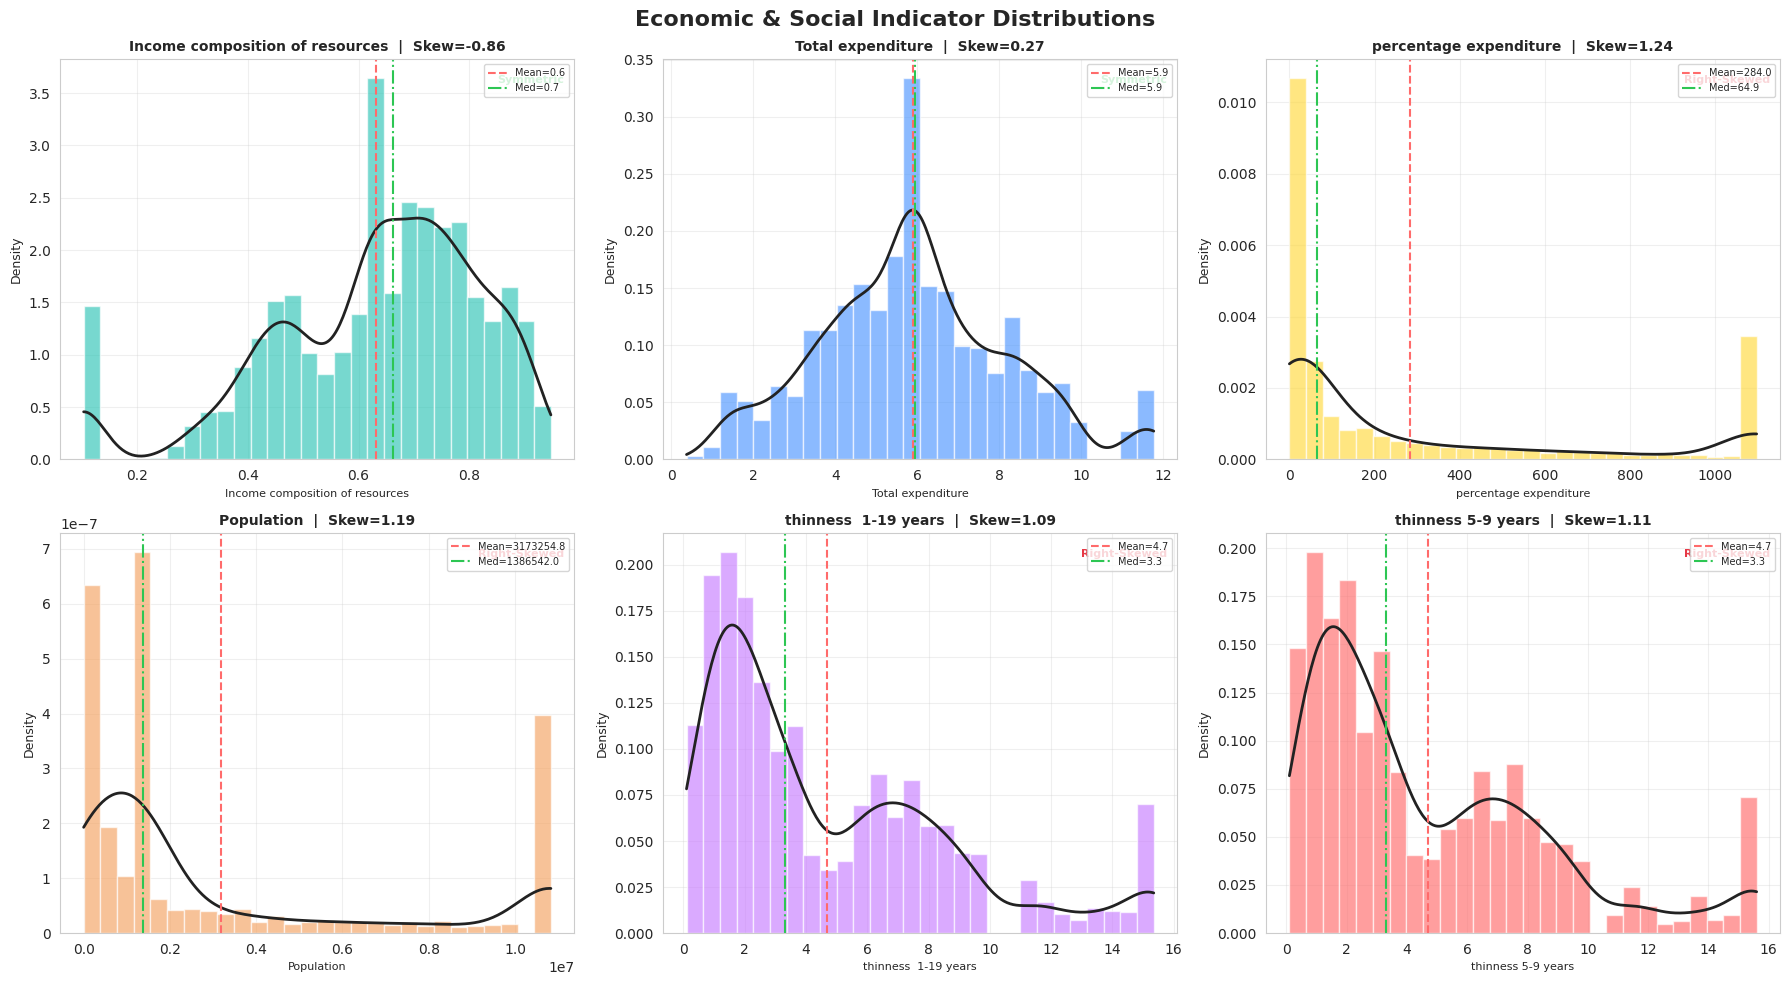

In [51]:
econ_feats=['Income composition of resources','Total expenditure',
            'percentage expenditure','Population',
            'thinness  1-19 years','thinness 5-9 years']
econ_colors=['#2EC4B6','#4D96FF','#FFD93D','#F4A261','#C77DFF','#FF6B6B']

fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle('Economic & Social Indicator Distributions',fontsize=16,fontweight='bold')
axes_flat=axes.flatten()

for i,col in enumerate(econ_feats):
    ax=axes_flat[i]
    c=econ_colors[i]
    data=df[col].dropna()
    ax.hist(data,bins=28,color=c,alpha=0.65,edgecolor='white',density=True)
    try:
        kde=gaussian_kde(data)
        xr=np.linspace(data.min(),data.max(),300)
        ax.plot(xr,kde(xr),color='#222222',lw=2)
    except Exception:
        pass
    skew_val=data.skew()
    ax.axvline(data.mean(),color='#FF6B6B',lw=1.5,linestyle='--',label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(),color='#2DC653',lw=1.5,linestyle='-.',label=f'Med={data.median():.1f}')
    ax.set_title(f'{col}  |  Skew={skew_val:.2f}',fontweight='bold',fontsize=10)
    ax.set_xlabel(col,fontsize=8)
    ax.set_ylabel('Density',fontsize=9)
    tag='Right-Skewed' if skew_val>1 else ('Left-Skewed' if skew_val<-1 else 'Symmetric')
    color_tag='#E63946' if abs(skew_val)>1 else '#2DC653'
    ax.text(0.98,0.94,tag,transform=ax.transAxes,ha='right',
            fontsize=8,color=color_tag,fontweight='bold')
    ax.legend(fontsize=7,loc='upper right')

plt.tight_layout()
plt.show()


### Economic & Social Indicator Distributions

**Income Composition of Resources**
- Approximately symmetric, centered around 0.65. This is the Human Development Index-like measure combining education, income, and life expectancy sub-indices.

**Total Expenditure**
- Mildly right-skewed, with most nations spending 4–8% of GDP on health. A few nations with universal healthcare systems extend the upper tail.

**Percentage Expenditure**
- Heavily right-skewed — reflects that high-GDP nations spend far more in absolute terms, making the distribution highly unequal.

**Population**
- Extremely right-skewed — driven by China and India which are orders of magnitude larger than most nations. Log transformation is essential for this variable.

**Thinness (1–19 years and 5–9 years)**
- Both right-skewed, reflecting that the majority of nations have low thinness prevalence, while South Asian nations occupy the upper tail.


---
#### Section 4 — Category Distribution

This section examines the distribution of the only categorical feature: **development status**. Both a count chart and a pie chart are used to illustrate the class imbalance.


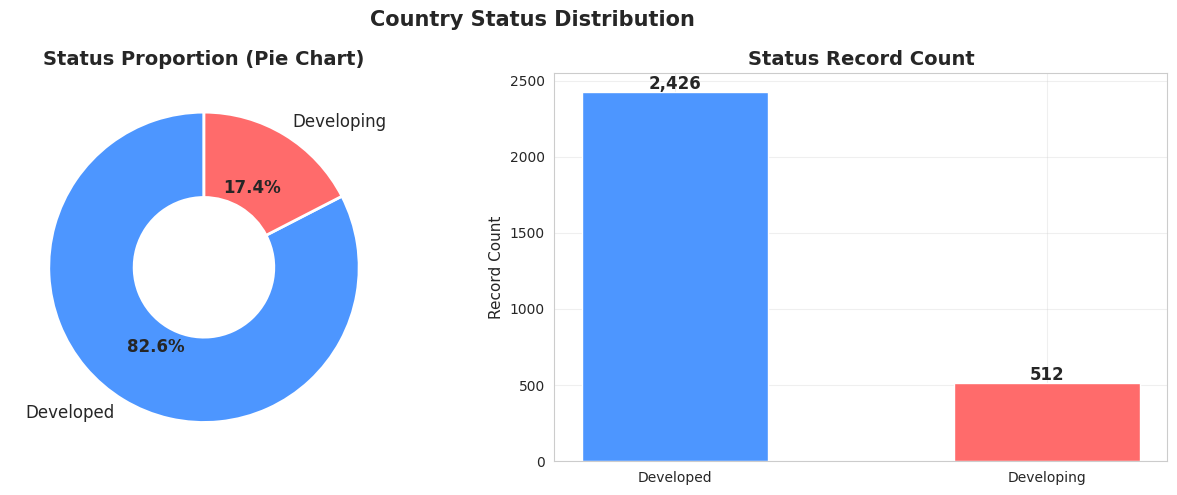

In [52]:
status_counts=df['Status'].value_counts() if df['Status'].dtype==object else df['Status'].map({0:'Developing',1:'Developed'}).value_counts()

fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle('Country Status Distribution',fontsize=15,fontweight='bold')

wedges,texts,autotexts=axes[0].pie(
    status_counts,labels=status_counts.index,autopct='%1.1f%%',
    colors=['#4D96FF','#FF6B6B'],startangle=90,
    wedgeprops=dict(width=0.55,edgecolor='white',linewidth=2),
    textprops={'fontsize':12}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Status Proportion (Pie Chart)')

bars=axes[1].bar(status_counts.index,status_counts.values,
                 color=['#4D96FF','#FF6B6B'],edgecolor='white',width=0.5)
for bar,val in zip(bars,status_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,
                 f'{val:,}',ha='center',fontweight='bold',fontsize=12)
axes[1].set_ylabel('Record Count')
axes[1].set_title('Status Record Count')

plt.tight_layout()
plt.show()


### Category Distribution

**Class Imbalance**
- ~82% of records are from Developing nations and ~18% from Developed nations.
- This reflects the real-world global distribution of countries by development status.

**Implications for Analysis**
- Any group comparison between Developed and Developing must account for the unequal sample sizes.
- Statistical conclusions about the Developed group are based on a much smaller sample and carry wider uncertainty.


---
#### Section 5 — Boxplot Analysis (Outlier + Spread)

Boxplots compactly convey five statistics for each feature: minimum, Q1 (25th percentile), median, Q3 (75th percentile), and maximum (excluding outliers shown as dots). This section focuses on the six most analytically important features.


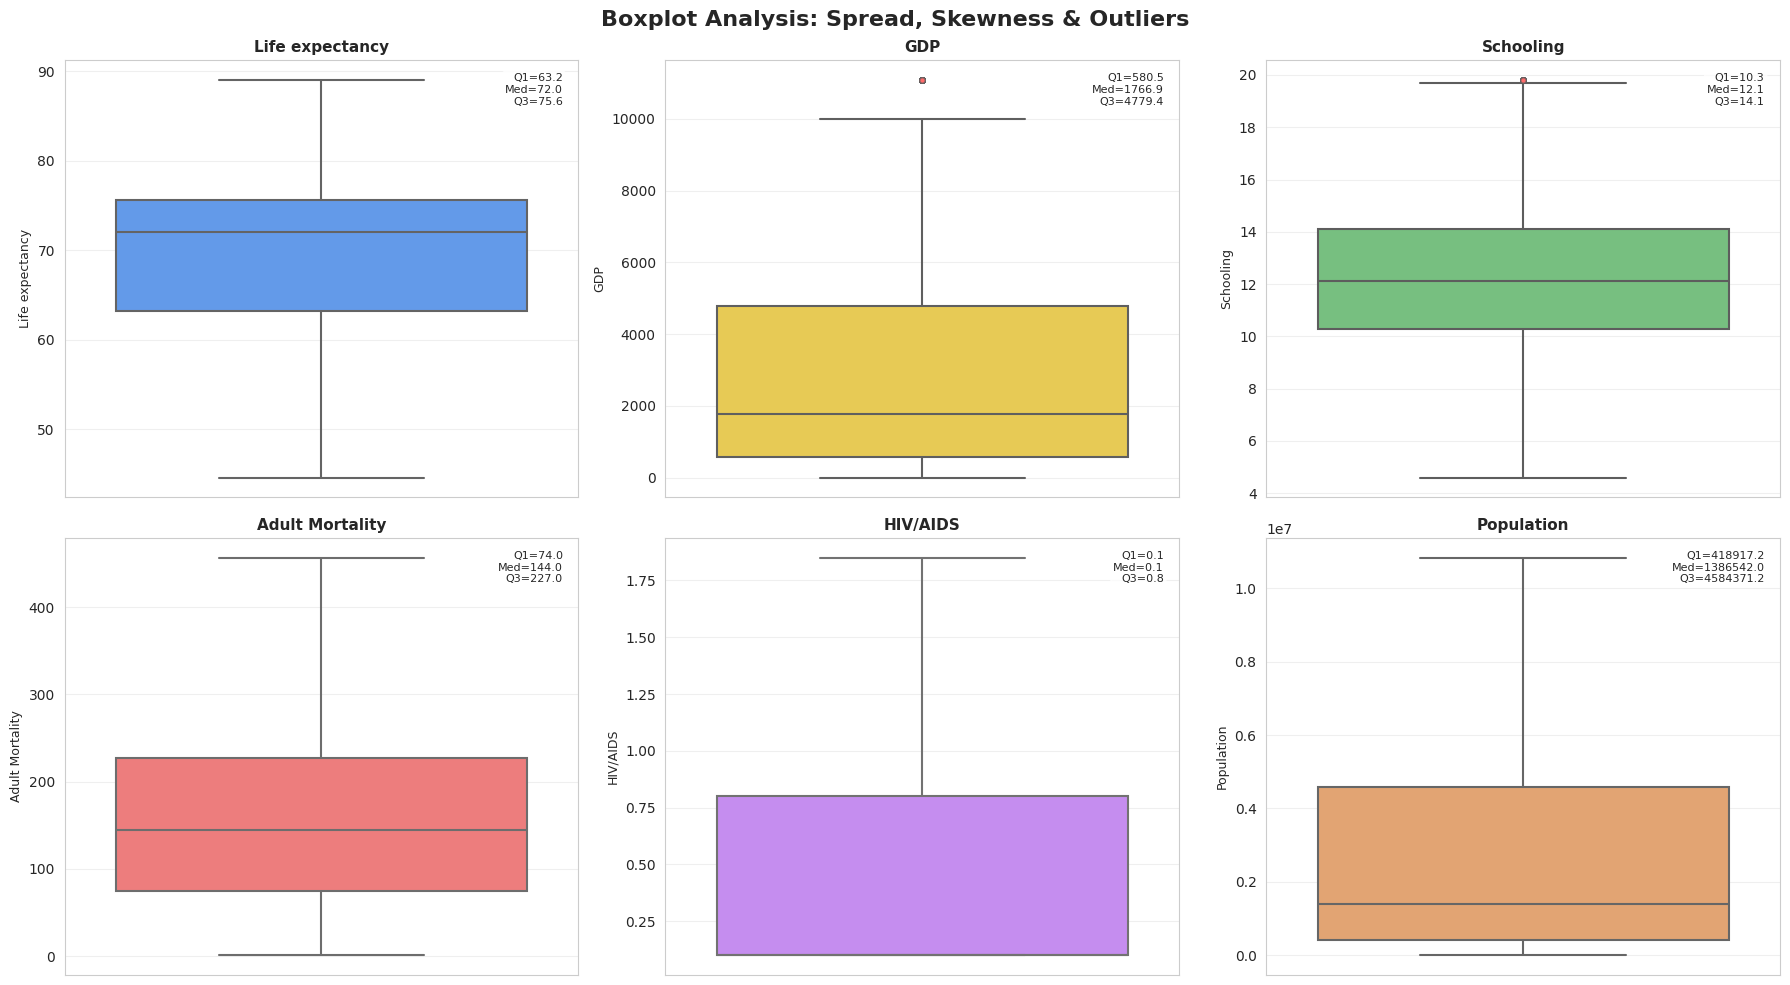

In [53]:
box_feats=['Life expectancy','GDP','Schooling','Adult Mortality','HIV/AIDS','Population']
box_colors=['#4D96FF','#FFD93D','#6BCB77','#FF6B6B','#C77DFF','#F4A261']

fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle('Boxplot Analysis: Spread, Skewness & Outliers',
             fontsize=16,fontweight='bold')
axes_flat=axes.flatten()

for i,col in enumerate(box_feats):
    ax=axes_flat[i]
    c=box_colors[i]
    sns.boxplot(y=df[col],ax=ax,color=c,linewidth=1.5,
                flierprops={'marker':'o','markerfacecolor':'#FF6B6B','markersize':4,'alpha':0.5})
    ax.set_title(f'{col}',fontweight='bold',fontsize=11)
    ax.set_ylabel(col,fontsize=9)
    q1,med,q3=df[col].quantile([0.25,0.5,0.75])
    ax.text(0.97,0.97,f'Q1={q1:.1f}\nMed={med:.1f}\nQ3={q3:.1f}',
            transform=ax.transAxes,ha='right',va='top',fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2',fc='white',alpha=0.7))

plt.tight_layout()
plt.show()


### Boxplot Analysis

**Life Expectancy**
- Median around 70 years with a tight IQR. Lower outliers represent nations below 50 years.

**GDP**
- Compact box with a very long upper whisker — confirming extreme right-skew driven by wealthy nations.

**Schooling**
- Compact and relatively symmetric, indicating consistent global access to at least basic education.

**Adult Mortality**
- The box sits at low-moderate rates, with the upper whisker extending significantly — driven by high-mortality Sub-Saharan nations.

**HIV/AIDS**
- Almost all records cluster near zero (box is at the bottom), with extreme upper outliers from nations with epidemic-level prevalence.

**Population**
- Extremely compressed box near zero with a massive upper tail — China and India are extreme outliers on any linear scale.


---
###Bivariate Analysis

**What is Bivariate Analysis?**

Bivariate analysis examines the relationship between two variables simultaneously to identify correlations, trends, and conditional differences. It moves beyond understanding individual features to asking: *how does X relate to Y?*

**Why it Matters**
- Identifies which features are the strongest predictors of the target variable (Life Expectancy).
- Reveals the direction and strength of relationships (positive, negative, weak, strong).
- Highlights group-level differences between Developed and Developing nations.
- Guides feature selection for modelling by separating useful predictors from noise.

**Methods Used**

- **Scatter Plot with Trend Line** — Visualises the relationship between two continuous variables; the trend line (linear regression fit) shows the direction and approximate slope.
- **Grouped Line Chart** — Shows how an average value changes across discrete categories (e.g., GDP quartile groups).
- **Strip Plot + Box Overlay** — Combines individual data point visibility with boxplot summary statistics for group comparisons.
- **Pair Plot** — Shows all pairwise scatter plots for a selected set of features simultaneously, coloured by group.
- **Time Series Line Plot** — Tracks how a variable changes over years.


---
#### Section 1 — Life Expectancy vs Key Factors

The following plots examine the six strongest individual predictors of Life Expectancy: GDP, Schooling, Adult Mortality, HIV/AIDS, Income Composition, and BMI. Each scatter plot includes a linear trend line and the Pearson correlation coefficient.


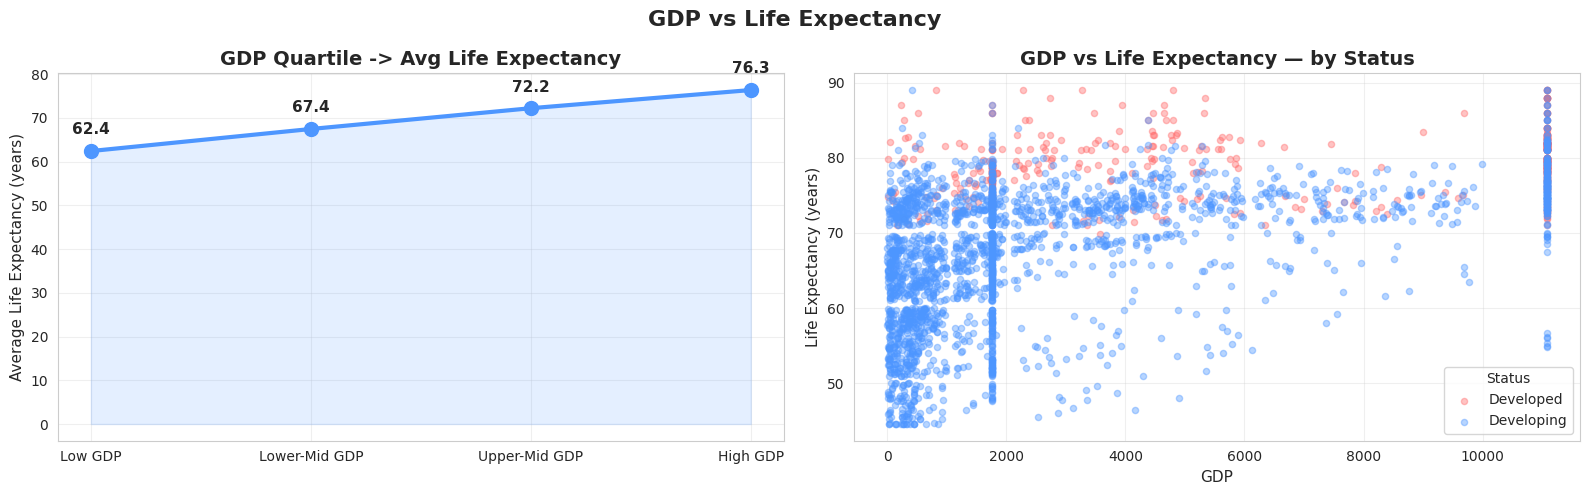

In [24]:
df['GDP_group']=pd.qcut(df['GDP'],4,
                         labels=['Low GDP','Lower-Mid GDP','Upper-Mid GDP','High GDP'])
gdp_avg=df.groupby('GDP_group',observed=False)['Life expectancy'].mean()

fig,axes=plt.subplots(1,2,figsize=(16,5))
fig.suptitle('GDP vs Life Expectancy',fontsize=16,fontweight='bold')

axes[0].plot(gdp_avg.index,gdp_avg.values,marker='o',
             linewidth=3,color='#4D96FF',markersize=10)
for x,y in zip(gdp_avg.index,gdp_avg.values):
    axes[0].annotate(f'{y:.1f}',(x,y),textcoords='offset points',
                     xytext=(0,12),ha='center',fontweight='bold',fontsize=11)
axes[0].fill_between(range(len(gdp_avg)),gdp_avg.values,alpha=0.15,color='#4D96FF')
axes[0].set_xticks(range(len(gdp_avg)))
axes[0].set_xticklabels(gdp_avg.index)
axes[0].set_ylabel('Average Life Expectancy (years)')
axes[0].set_title('GDP Quartile -> Avg Life Expectancy')

status_labels=df['Status'].map({0:'Developing',1:'Developed'}) if df['Status'].dtype!=object else df['Status']
palette_map={'Developed':'#FF6B6B','Developing':'#4D96FF'}
for status,grp in df.groupby(status_labels):
    axes[1].scatter(grp['GDP'],grp['Life expectancy'],
                    alpha=0.4,s=20,label=status,
                    color=palette_map.get(str(status),'#888'))
axes[1].set_xlabel('GDP')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('GDP vs Life Expectancy — by Status')
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()


### GDP vs Life Expectancy

**Quartile Analysis**
- Moving from the lowest to highest GDP quartile increases average life expectancy by approximately 15 years — one of the strongest single-feature effects in the entire dataset.

**Scatter by Status**
- Developed nations cluster at higher GDP and higher life expectancy values.
- Developing nations span a wide range, reflecting heterogeneity in economic performance within the group.

**Key Takeaway**
- GDP is a strong positive predictor of life expectancy, but the relationship is nonlinear — gains diminish at very high GDP levels, suggesting a saturation effect beyond a certain wealth threshold.


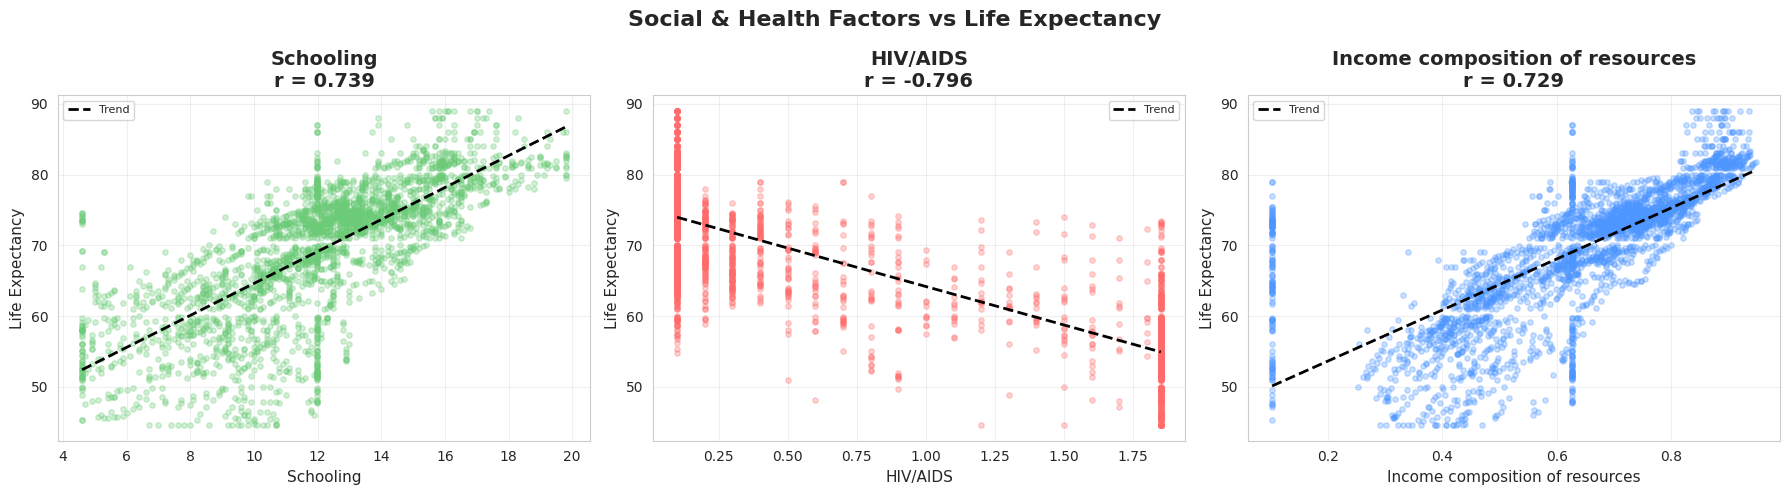

In [25]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Social & Health Factors vs Life Expectancy',fontsize=16,fontweight='bold')

pairs=[('Schooling','#6BCB77'),('HIV/AIDS','#FF6B6B'),('Income composition of resources','#4D96FF')]
for ax,(feat,col) in zip(axes,pairs):
    ax.scatter(df[feat],df['Life expectancy'],alpha=0.3,s=15,color=col)
    m=df[[feat,'Life expectancy']].dropna()
    z=np.polyfit(m[feat],m['Life expectancy'],1)
    p=np.poly1d(z)
    xr=np.linspace(m[feat].min(),m[feat].max(),200)
    ax.plot(xr,p(xr),'k--',lw=2,label='Trend')
    corr_val=df[[feat,'Life expectancy']].corr().iloc[0,1]
    ax.set_title(f'{feat}\nr = {corr_val:.3f}',fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Life Expectancy')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Schooling, HIV/AIDS, and Income Composition vs Life Expectancy

**Schooling (r ≈ +0.75)**
- The strongest positive predictor in the dataset. Each additional year of schooling is associated with approximately 1.5–2 additional years of life expectancy.
- The relationship is close to linear, with very little scatter at the high-schooling end.

**HIV/AIDS (r ≈ −0.57)**
- Strong negative relationship. Nations with high HIV prevalence show dramatically lower life expectancy.
- Sub-Saharan African nations dominate the lower-right region of the scatter.

**Income Composition (r ≈ +0.72)**
- Very strong positive relationship, similar in magnitude to schooling. This composite index (combining education, income, and life sub-indices) is a direct proxy for overall development level.


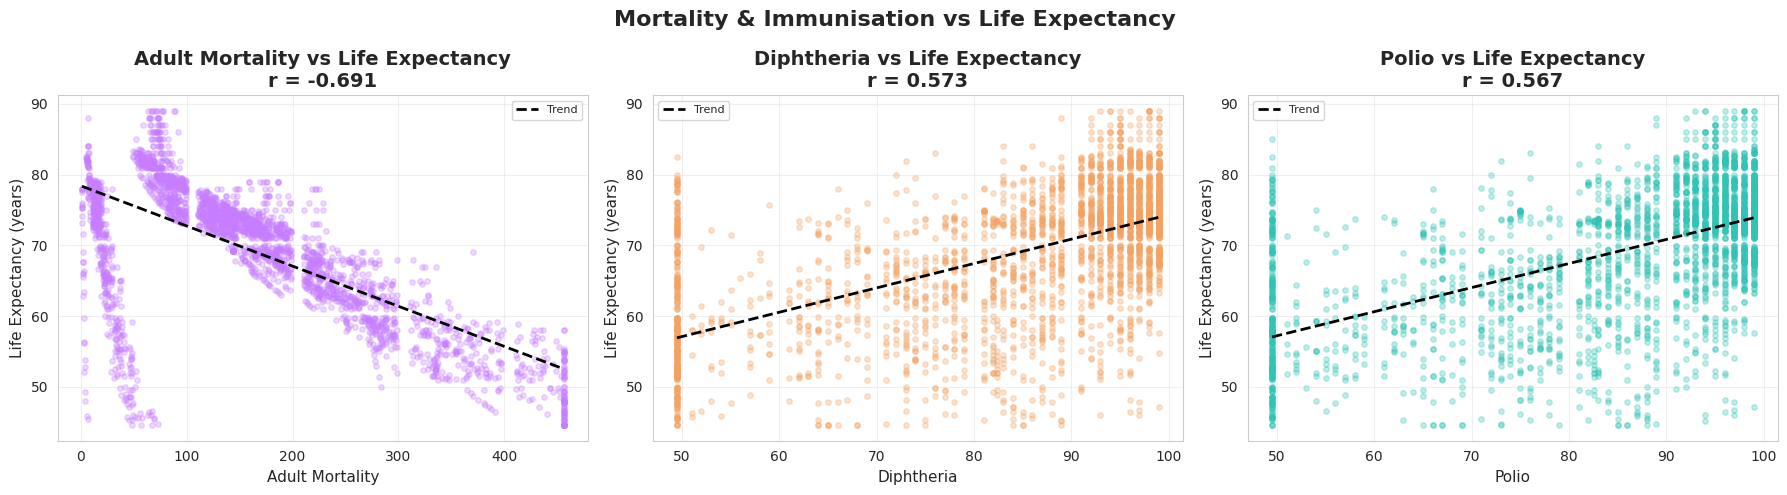

In [26]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Mortality & Immunisation vs Life Expectancy',fontsize=16,fontweight='bold')

pairs2=[('Adult Mortality','#C77DFF'),('Diphtheria','#F4A261'),('Polio','#2EC4B6')]
for ax,(feat,col) in zip(axes,pairs2):
    ax.scatter(df[feat],df['Life expectancy'],alpha=0.3,s=15,color=col)
    m=df[[feat,'Life expectancy']].dropna()
    z=np.polyfit(m[feat],m['Life expectancy'],1)
    p=np.poly1d(z)
    xr=np.linspace(m[feat].min(),m[feat].max(),200)
    ax.plot(xr,p(xr),'k--',lw=2,label='Trend')
    corr_val=df[[feat,'Life expectancy']].corr().iloc[0,1]
    ax.set_title(f'{feat} vs Life Expectancy\nr = {corr_val:.3f}',fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Life Expectancy (years)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Adult Mortality, Diphtheria, and Polio vs Life Expectancy

**Adult Mortality**
- Strong negative correlation — as expected, higher mortality rates directly reduce life expectancy. The relationship is close to linear with minimal scatter.

**Diphtheria Immunisation**
- Positive correlation — nations with high Diphtheria coverage tend to have longer life expectancy, reflecting that strong immunisation programmes are part of broader functional healthcare systems.

**Polio Immunisation**
- Similar positive trend to Diphtheria. Nations with low immunisation rates cluster at lower life expectancy values, reinforcing the public health importance of childhood vaccination.


---
#### Section 2 — Mortality Analysis

This section explores the relationships between different mortality-related variables to identify compound risk factors and interdependencies.


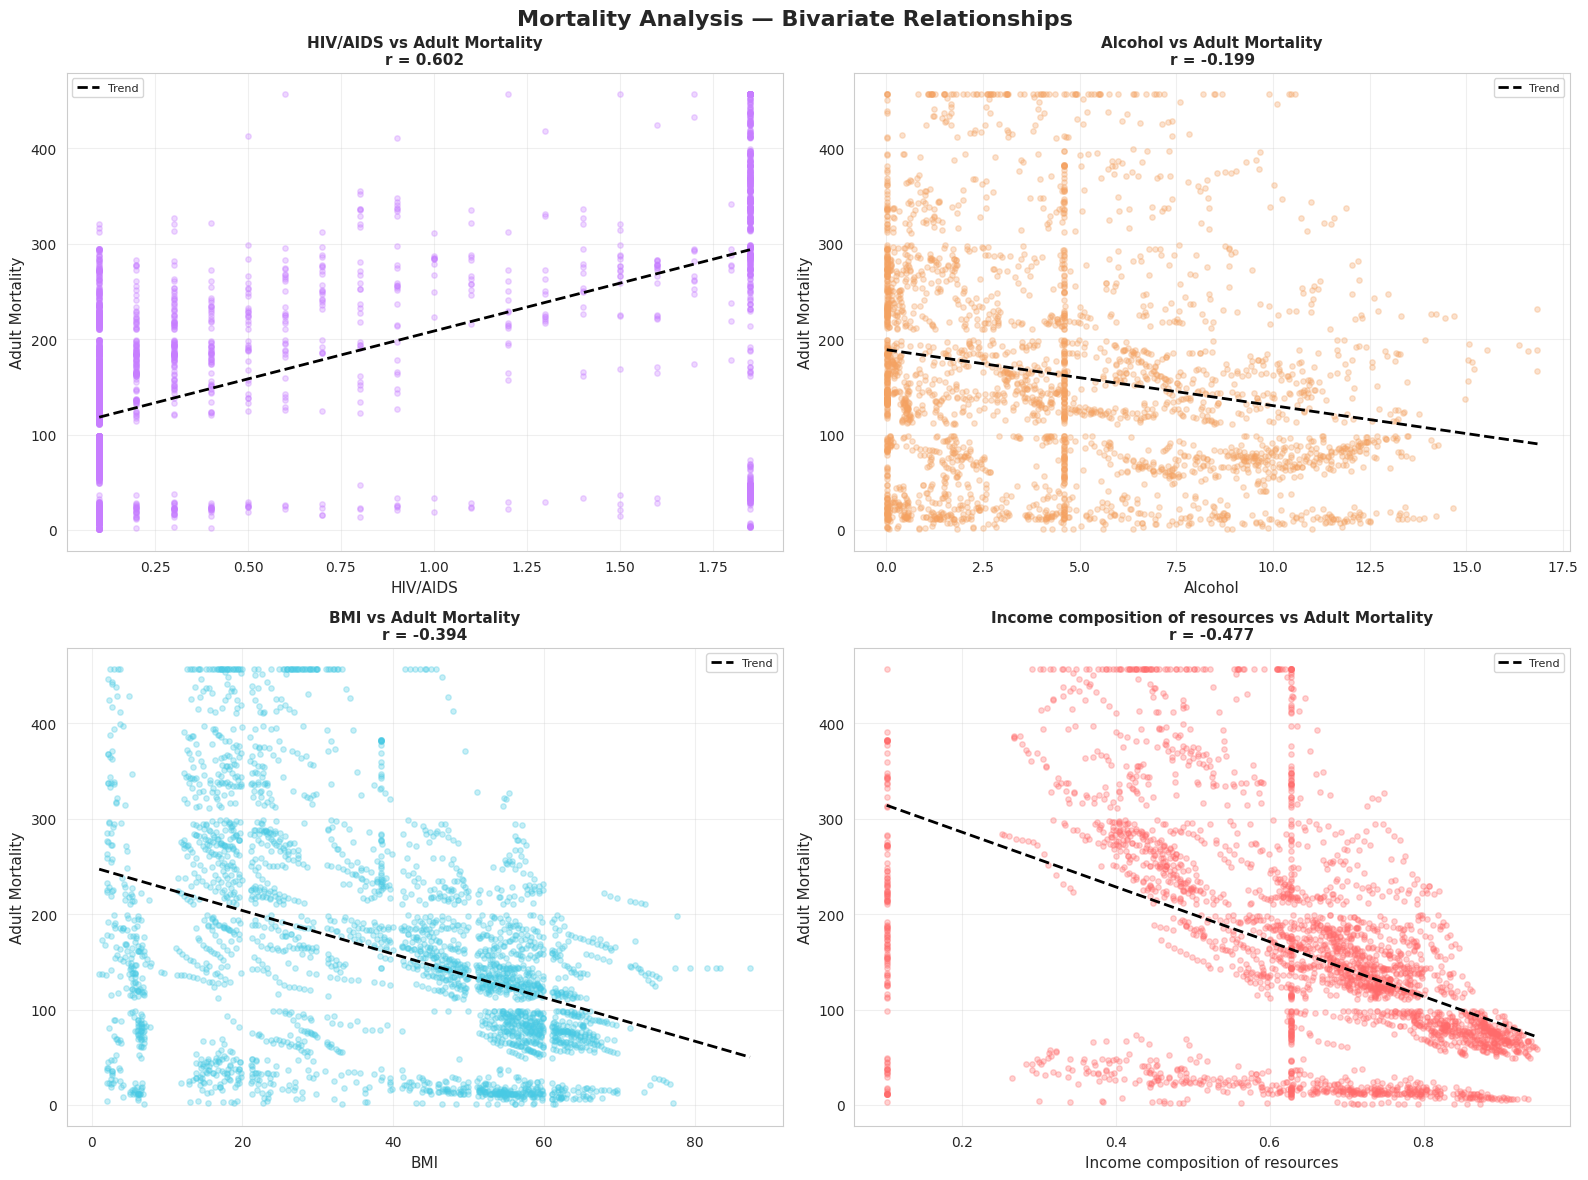

In [27]:
fig,axes=plt.subplots(2,2,figsize=(16,12))
fig.suptitle('Mortality Analysis — Bivariate Relationships',fontsize=16,fontweight='bold')
axes_flat=axes.flatten()

mort_pairs=[
    ('HIV/AIDS','Adult Mortality','#C77DFF'),
    ('Alcohol','Adult Mortality','#F4A261'),
    ('BMI','Adult Mortality','#48CAE4'),
    ('Income composition of resources','Adult Mortality','#FF6B6B'),
]
for ax,(feat1,feat2,col) in zip(axes_flat,mort_pairs):
    ax.scatter(df[feat1],df[feat2],alpha=0.3,s=15,color=col)
    m=df[[feat1,feat2]].dropna()
    z=np.polyfit(m[feat1],m[feat2],1)
    p=np.poly1d(z)
    xr=np.linspace(m[feat1].min(),m[feat1].max(),200)
    ax.plot(xr,p(xr),'k--',lw=2,label='Trend')
    corr_val=df[[feat1,feat2]].corr().iloc[0,1]
    ax.set_title(f'{feat1} vs {feat2}\nr = {corr_val:.3f}',fontweight='bold',fontsize=11)
    ax.set_xlabel(feat1)
    ax.set_ylabel(feat2)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Mortality Analysis

**HIV/AIDS vs Adult Mortality**
- Very strong positive correlation. HIV/AIDS remains the dominant infectious driver of adult mortality globally, particularly across Sub-Saharan African nations which cluster in the upper-right region.

**Alcohol vs Adult Mortality**
- Weak and mixed relationship. High-consuming European nations maintain low mortality rates due to strong healthcare infrastructure, while high mortality with low alcohol consumption occurs in disease-burdened nations.

**BMI vs Adult Mortality**
- Moderate negative correlation. Higher national BMI averages tend to coincide with lower adult mortality, likely reflecting that higher BMI nations generally have better nutrition and healthcare access.

**Income Composition vs Adult Mortality**
- Strong negative correlation. Nations with higher income composition (better human development) consistently exhibit lower adult mortality rates across all income levels.


---
#### Section 3 — Country Status Comparison

This section compares the distributions of key health and economic variables between Developed and Developing nations using strip plots with boxplot overlays. Strip plots show every individual data point while the boxplot summarises the group statistics.


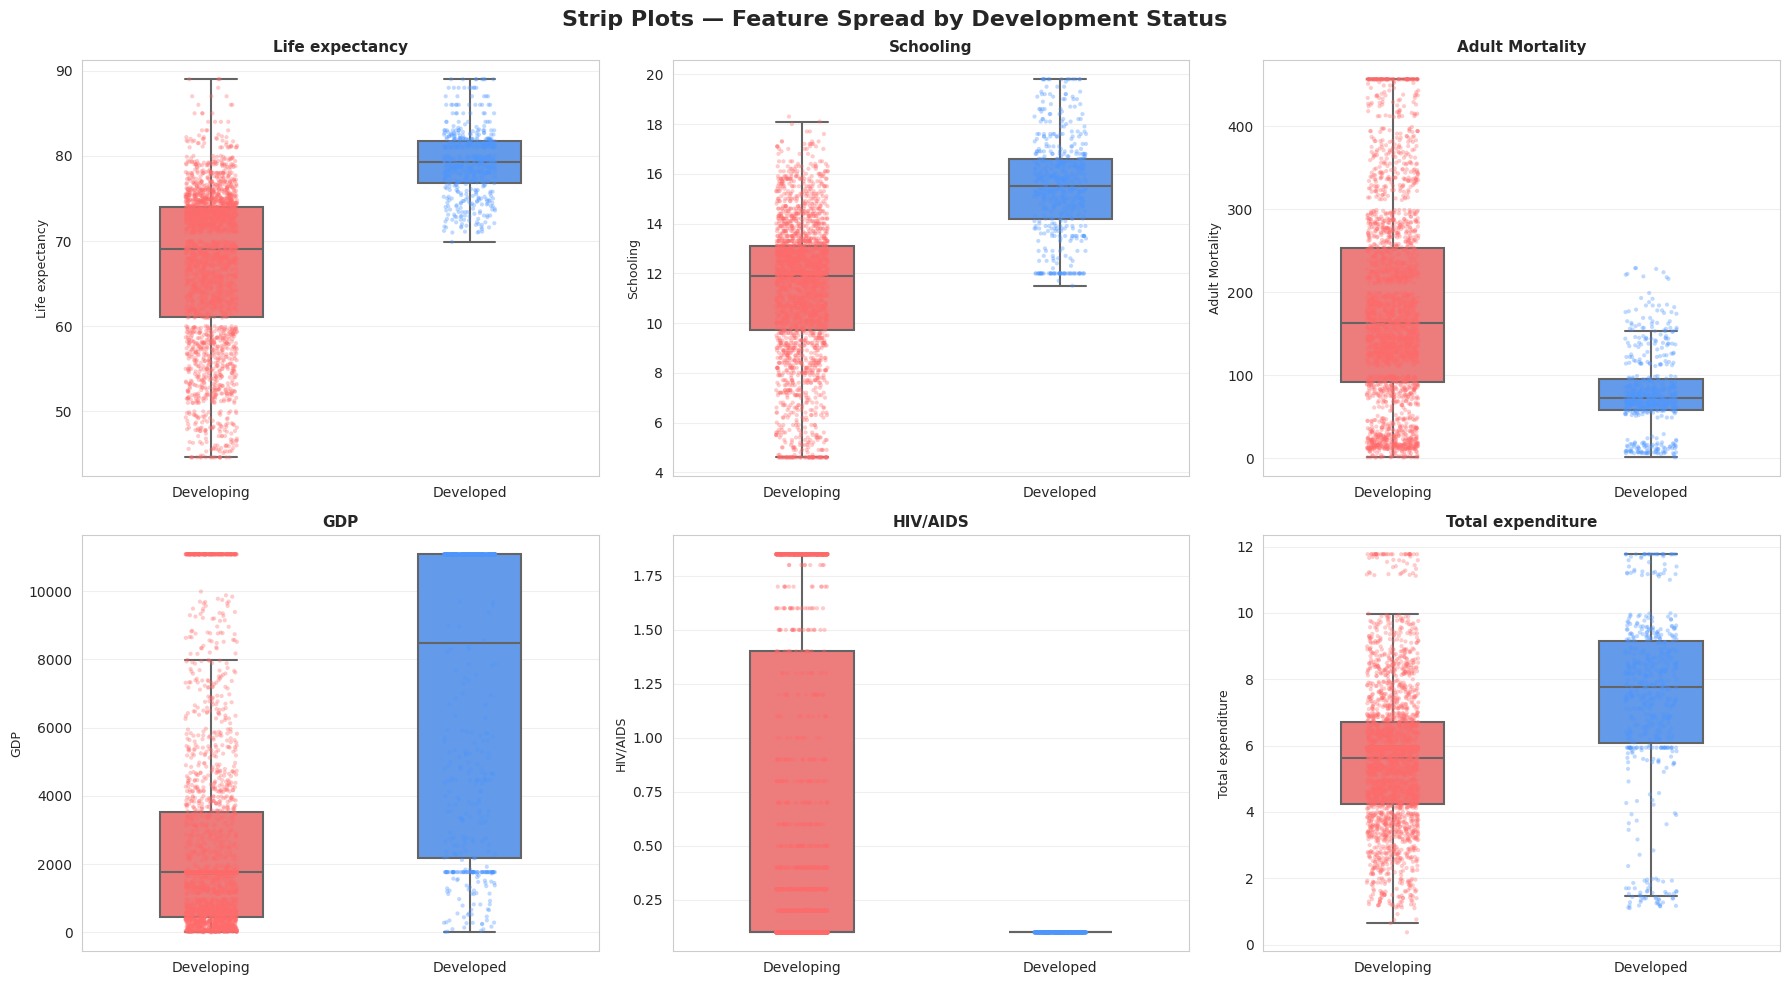

In [28]:
strip_feats=['Life expectancy','Schooling','Adult Mortality','GDP','HIV/AIDS','Total expenditure']
ncols=3
nrows=2

fig,axes=plt.subplots(nrows,ncols,figsize=(18,10))
fig.suptitle('Strip Plots — Feature Spread by Development Status',fontsize=16,fontweight='bold')
axes_flat=axes.flatten()

status_col=df['Status'] if df['Status'].dtype==object else df['Status'].map({0:'Developing',1:'Developed'})
df_s=df.copy();df_s['Status_Label']=status_col

for i,col in enumerate(strip_feats):
    ax=axes_flat[i]
    sns.stripplot(x='Status_Label',y=col,data=df_s,
                  palette=['#FF6B6B','#4D96FF'],alpha=0.35,jitter=True,size=3,ax=ax)
    sns.boxplot(x='Status_Label',y=col,data=df_s,
                palette=['#FF6B6B88','#4D96FF88'],ax=ax,
                linewidth=1.5,fliersize=0,width=0.4)
    ax.set_title(f'{col}',fontweight='bold',fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(col,fontsize=9)

plt.tight_layout()
plt.show()


### Country Status Comparison

**Life Expectancy**
- The developed group sits entirely above ~73 years, while developing nations span from ~40 to ~85 years — demonstrating far greater heterogeneity within the developing category.

**Schooling**
- Developed nations cluster tightly at 12–15 years. Developing nations show a wide spread from 2 to 14 years, reflecting large educational inequality within the group.

**Adult Mortality**
- Developing nations show a much higher and wider spread; some records exceed 500 per 1000 — representing catastrophically high mortality in conflict or disease-affected nations.

**GDP & Total Expenditure**
- Both show the same pattern: developed nations occupy a higher, tighter range while developing nations have wide spread at lower values.

**HIV/AIDS**
- Almost all developed nation records cluster near zero, while developing nations include the extreme outlier values seen in Sub-Saharan Africa.


---
#### Section 4 — Grouped Analysis

This section creates categorical groups from continuous variables (GDP groups, Income groups, Schooling levels) and compares their average Life Expectancy. Grouped analysis reveals non-linear threshold effects that scatter plots alone may obscure.


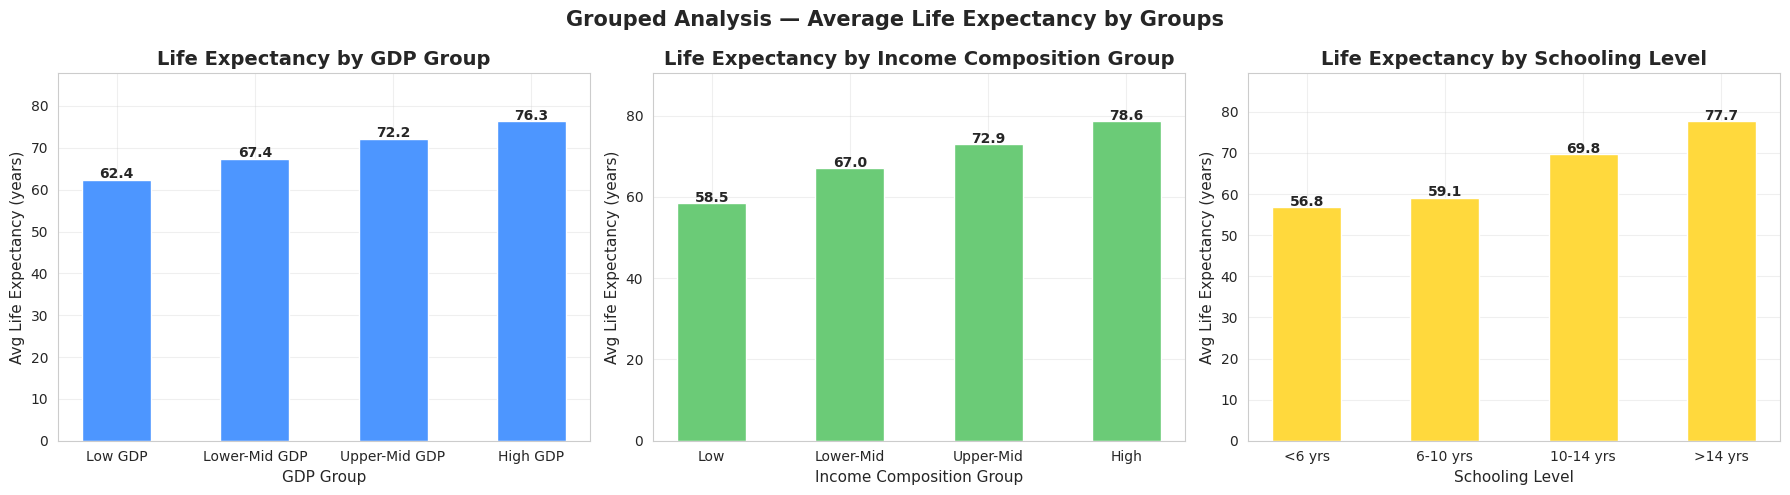

In [29]:
df['Income_group']=pd.qcut(df['Income composition of resources'],4,
                           labels=['Low','Lower-Mid','Upper-Mid','High'])
df['Schooling_group']=pd.cut(df['Schooling'],bins=[0,6,10,14,20],
                             labels=['<6 yrs','6-10 yrs','10-14 yrs','>14 yrs'])

fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Grouped Analysis — Average Life Expectancy by Groups',fontsize=15,fontweight='bold')

for ax,(col,label,color) in zip(axes,[
    ('GDP_group','GDP Group','#4D96FF'),
    ('Income_group','Income Composition Group','#6BCB77'),
    ('Schooling_group','Schooling Level','#FFD93D')
]):
    grp_avg=df.groupby(col,observed=False)['Life expectancy'].mean()
    bars=ax.bar(grp_avg.index,grp_avg.values,color=color,edgecolor='white',width=0.5)
    for bar,val in zip(bars,grp_avg.values):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,
                f'{val:.1f}',ha='center',fontsize=10,fontweight='bold')
    ax.set_title(f'Life Expectancy by {label}',fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Avg Life Expectancy (years)')
    ax.set_ylim(0,grp_avg.max()*1.15)

plt.tight_layout()
plt.show()


### Grouped Analysis

**GDP Groups**
- Clear stepwise increase from Low to High GDP — the high GDP group averages approximately 15 years more than the low GDP group, confirming GDP as a major driver.

**Income Composition Groups**
- The gradient is even steeper than GDP groups — the high income composition group averages over 20 years more than the low group, making it the single most discriminating grouped variable.

**Schooling Levels**
- Nations where average schooling exceeds 14 years have life expectancy above 77 years on average. Nations below 6 years average below 55 years — a 22-year gap driven entirely by education level.


---
#### Section 5 — Trend-Based Bivariate (Year vs Key Indicators)

This section tracks global averages of key indicators over the 2000–2015 period to identify directional trends and the overall trajectory of global health.


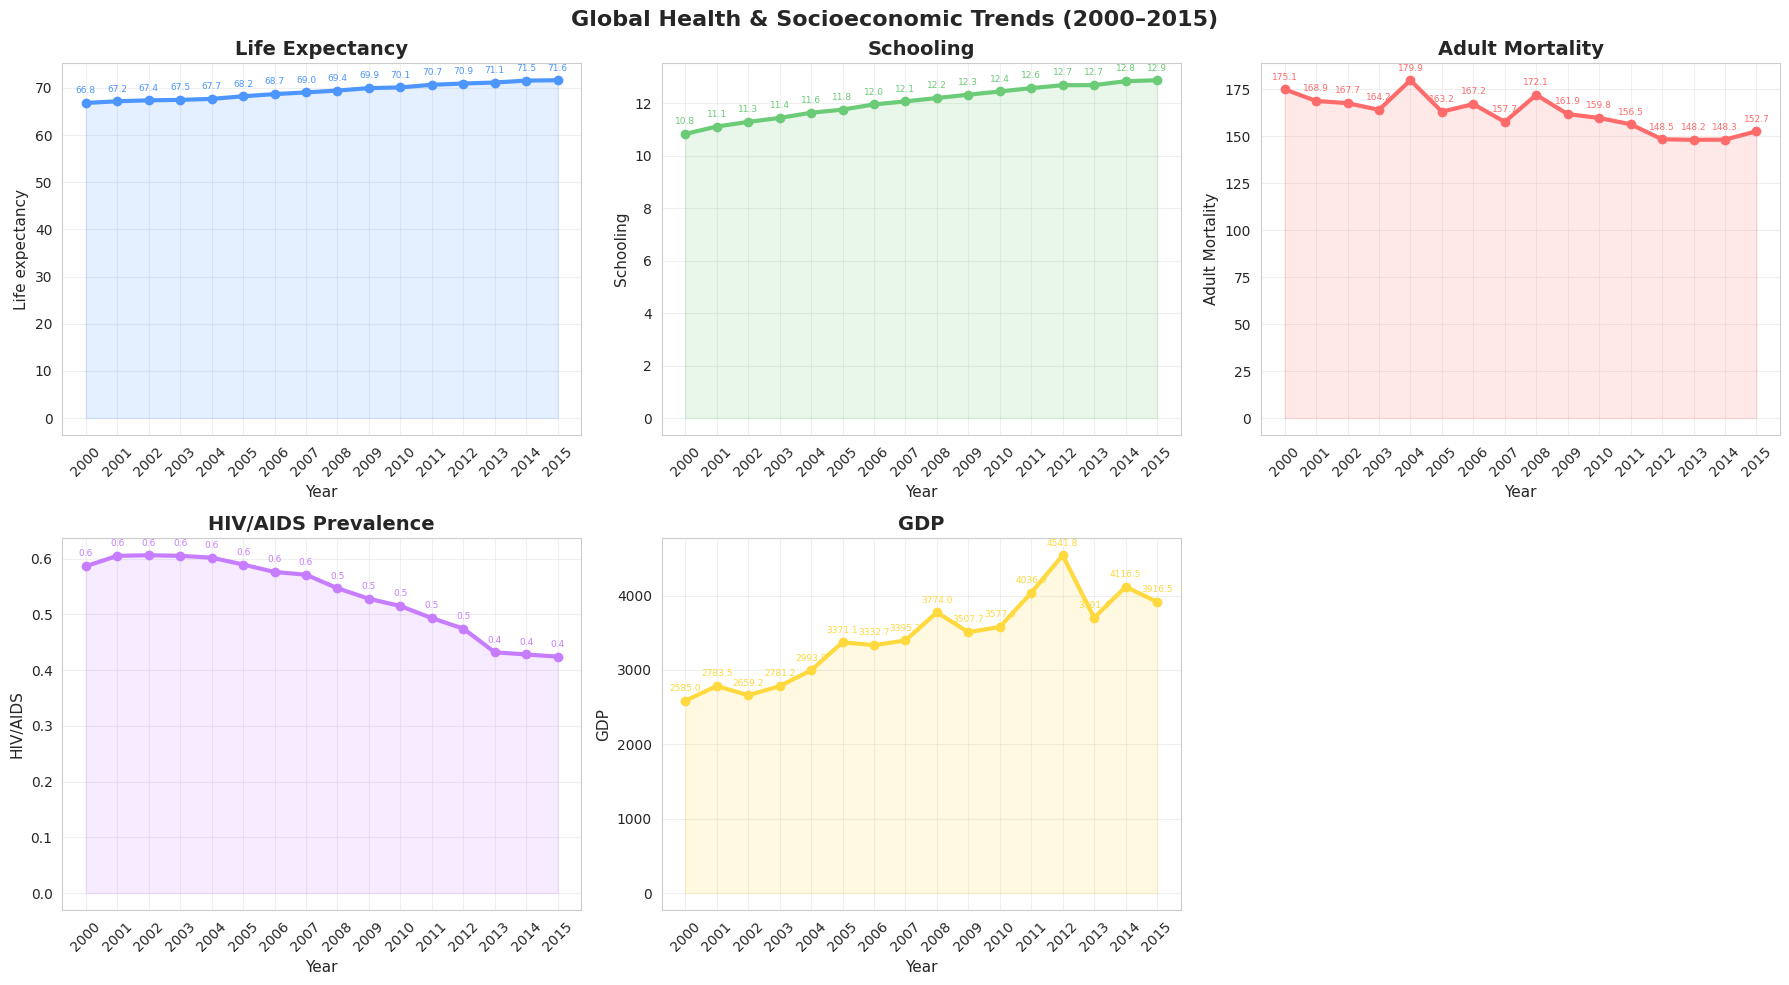

In [30]:
trend_cols=['Life expectancy','Schooling','Adult Mortality','HIV/AIDS','GDP']
trend_titles=['Life Expectancy','Schooling','Adult Mortality','HIV/AIDS Prevalence','GDP']
colors_ts=['#4D96FF','#6BCB77','#FF6B6B','#C77DFF','#FFD93D']

fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle('Global Health & Socioeconomic Trends (2000–2015)',fontsize=16,fontweight='bold')
axes_flat=axes.flatten()

for i,(col,title,c) in enumerate(zip(trend_cols,trend_titles,colors_ts)):
    trend=df.groupby('Year')[col].mean()
    ax=axes_flat[i]
    ax.plot(trend.index,trend.values,color=c,lw=3,marker='o',markersize=6)
    ax.fill_between(trend.index,trend.values,alpha=0.15,color=c)
    for yr,val in trend.items():
        ax.annotate(f'{val:.1f}',(yr,val),textcoords='offset points',
                    xytext=(0,7),ha='center',fontsize=6.5,color=c)
    ax.set_title(title,fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel(col)
    ax.set_xticks(trend.index)
    ax.tick_params(axis='x',rotation=45)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()


### Global Trends (2000–2015)

**Life Expectancy**
- Rose steadily from approximately 67 to 72 years — a 5-year improvement in 15 years, driven by reduced child mortality and improved access to antiretroviral therapy.

**Schooling**
- Consistent increase throughout the period, reflecting global investment in education and UNESCO-driven literacy campaigns.

**Adult Mortality**
- Declining trend, particularly after 2005, as treatment programmes and public health infrastructure expanded in low-income nations.

**HIV/AIDS**
- Peaked around 2004–2005 and then declined sharply — a direct result of international PEPFAR and UNAIDS treatment programmes expanding access to antiretroviral drugs.

**GDP**
- Generally increasing, with a brief plateau around 2008–2009 corresponding to the global financial crisis.


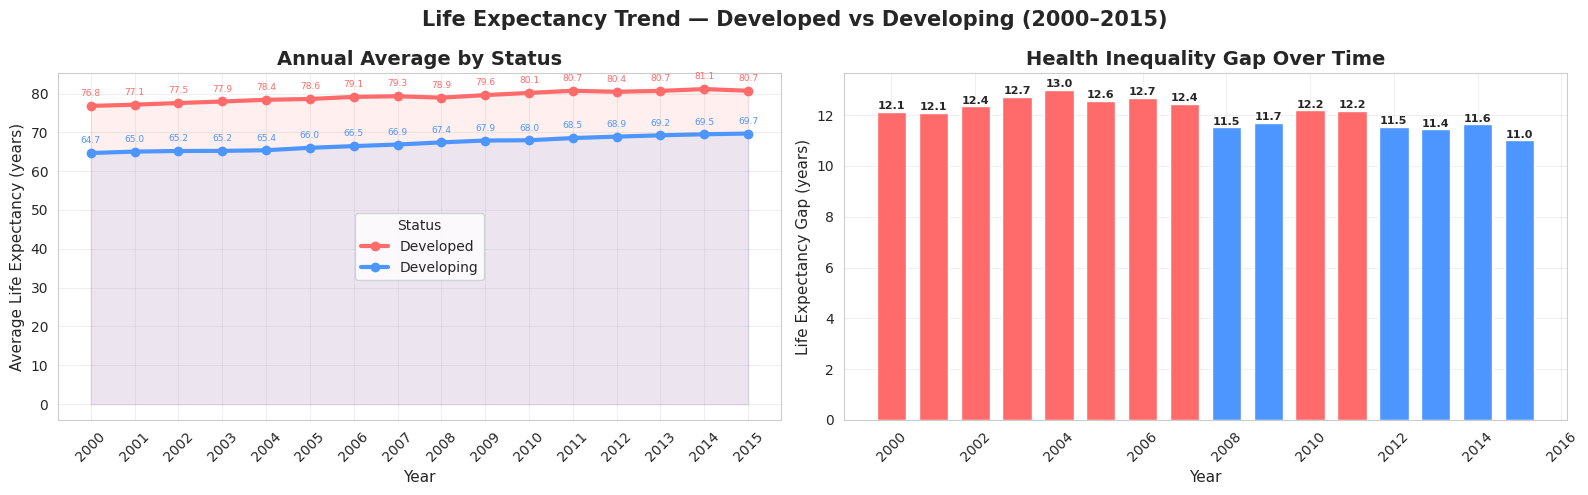

In [31]:
status_col=df['Status'] if df['Status'].dtype==object else df['Status'].map({0:'Developing',1:'Developed'})
df_ts=df.copy();df_ts['Status_Label']=status_col

fig,axes=plt.subplots(1,2,figsize=(16,5))
fig.suptitle('Life Expectancy Trend — Developed vs Developing (2000–2015)',fontsize=15,fontweight='bold')

for status,c in [('Developed','#FF6B6B'),('Developing','#4D96FF')]:
    sub=df_ts[df_ts['Status_Label']==status].groupby('Year')['Life expectancy'].mean()
    axes[0].plot(sub.index,sub.values,color=c,lw=3,marker='o',markersize=6,label=status)
    axes[0].fill_between(sub.index,sub.values,alpha=0.1,color=c)
    for yr,val in sub.items():
        axes[0].annotate(f'{val:.1f}',(yr,val),textcoords='offset points',
                         xytext=(0,7),ha='center',fontsize=6.5,color=c)

axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Life Expectancy (years)')
axes[0].set_title('Annual Average by Status')
axes[0].legend(title='Status')
axes[0].set_xticks(df_ts['Year'].unique())
axes[0].tick_params(axis='x',rotation=45)

devd=df_ts[df_ts['Status_Label']=='Developed'].groupby('Year')['Life expectancy'].mean()
devg=df_ts[df_ts['Status_Label']=='Developing'].groupby('Year')['Life expectancy'].mean()
gap=devd-devg
axes[1].bar(gap.index,gap.values,
            color=['#FF6B6B' if v>gap.mean() else '#4D96FF' for v in gap.values],
            edgecolor='white',width=0.7)
for yr,val in gap.items():
    axes[1].text(yr,val+0.1,f'{val:.1f}',ha='center',fontsize=8,fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Life Expectancy Gap (years)')
axes[1].set_title('Health Inequality Gap Over Time')
axes[1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()


### Life Expectancy Trend by Development Status

**Parallel Improvement**
- Both Developed and Developing nations improved over the 2000–2015 period, but at roughly equal rates — the gap remained persistently wide at approximately 11–12 years.

**Inequality Gap**
- The bar chart confirms the gap did not narrow significantly across 15 years, suggesting that while developing nations are improving, the pace of improvement is not fast enough to close the structural health divide.

**Implication**
- The persistent gap highlights the need for targeted global health policy rather than general economic growth alone.


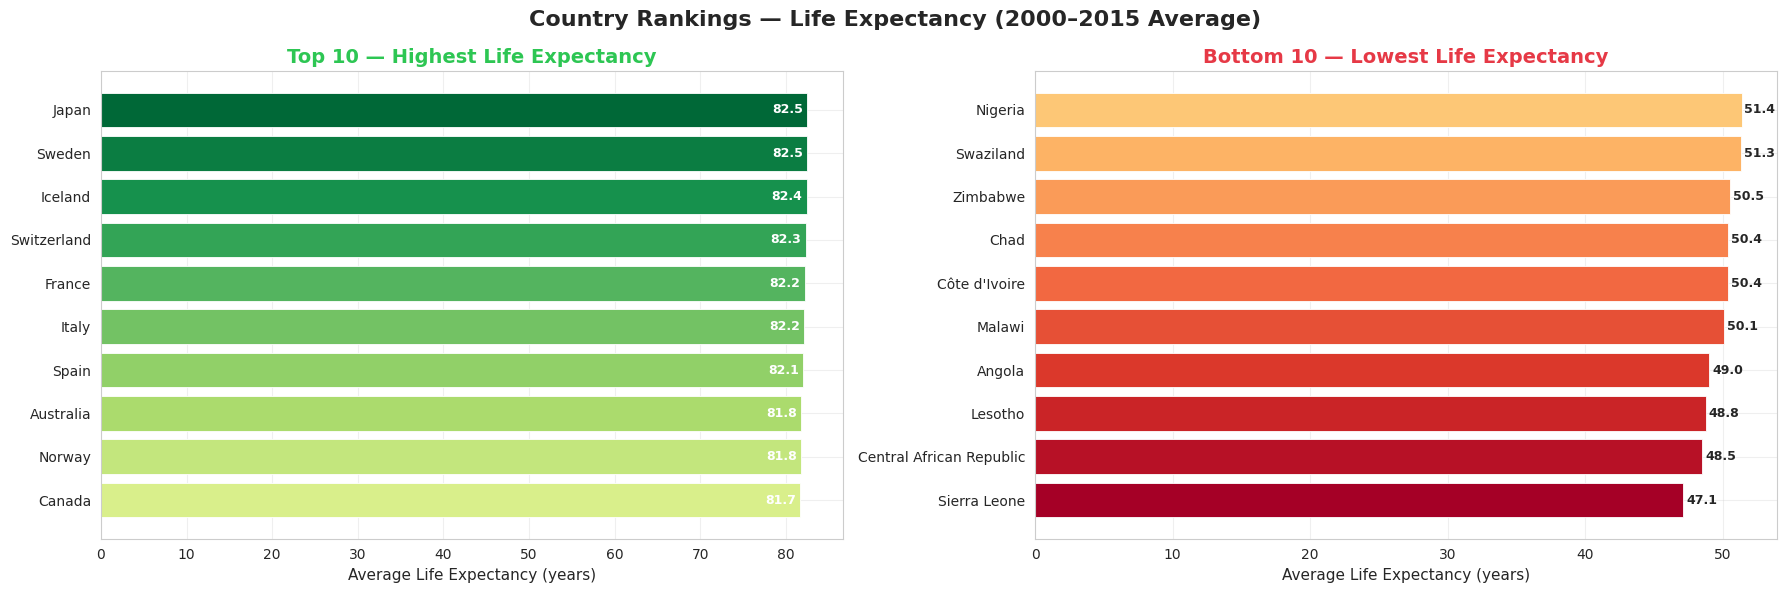

In [32]:
top_life=df.groupby('Country')['Life expectancy'].mean().sort_values(ascending=False).head(10)
bottom_life=df.groupby('Country')['Life expectancy'].mean().sort_values().head(10)

fig,axes=plt.subplots(1,2,figsize=(18,6))
fig.suptitle('Country Rankings — Life Expectancy (2000–2015 Average)',fontsize=16,fontweight='bold')

colors_top=plt.cm.RdYlGn(np.linspace(0.6,1.0,10))
bars=axes[0].barh(range(10),top_life.values[::-1],color=colors_top,edgecolor='white',linewidth=0.6)
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top_life.index[::-1],fontsize=10)
axes[0].set_title('Top 10 — Highest Life Expectancy',color='#2DC653')
axes[0].set_xlabel('Average Life Expectancy (years)')
for bar,val in zip(bars,top_life.values[::-1]):
    axes[0].text(bar.get_width()-0.5,bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}',va='center',ha='right',fontweight='bold',fontsize=9,color='white')

colors_bot=plt.cm.RdYlGn(np.linspace(0.0,0.35,10))
bars2=axes[1].barh(range(10),bottom_life.values,color=colors_bot,edgecolor='white',linewidth=0.6)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(bottom_life.index,fontsize=10)
axes[1].set_title('Bottom 10 — Lowest Life Expectancy',color='#E63946')
axes[1].set_xlabel('Average Life Expectancy (years)')
for bar,val in zip(bars2,bottom_life.values):
    axes[1].text(bar.get_width()+0.2,bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}',va='center',fontsize=9,fontweight='bold')

plt.tight_layout()
plt.show()


### Country Rankings

**Top 10**
- Exclusively high-income nations — Japan, Sweden, Iceland, Switzerland — with life expectancies exceeding 80 years.
- These nations combine strong universal healthcare systems with high education levels and economic stability.

**Bottom 10**
- Concentrated in Sub-Saharan Africa — Sierra Leone, Central African Republic, Lesotho — with life expectancies below 50 years.
- Driven by extreme poverty, high HIV/AIDS burden, weak health infrastructure, and in some cases, conflict.

**Global Inequality**
- The 30+ year gap between top and bottom nations is the central finding of this entire project — it encapsulates every socioeconomic and disease-related driver identified in this analysis.


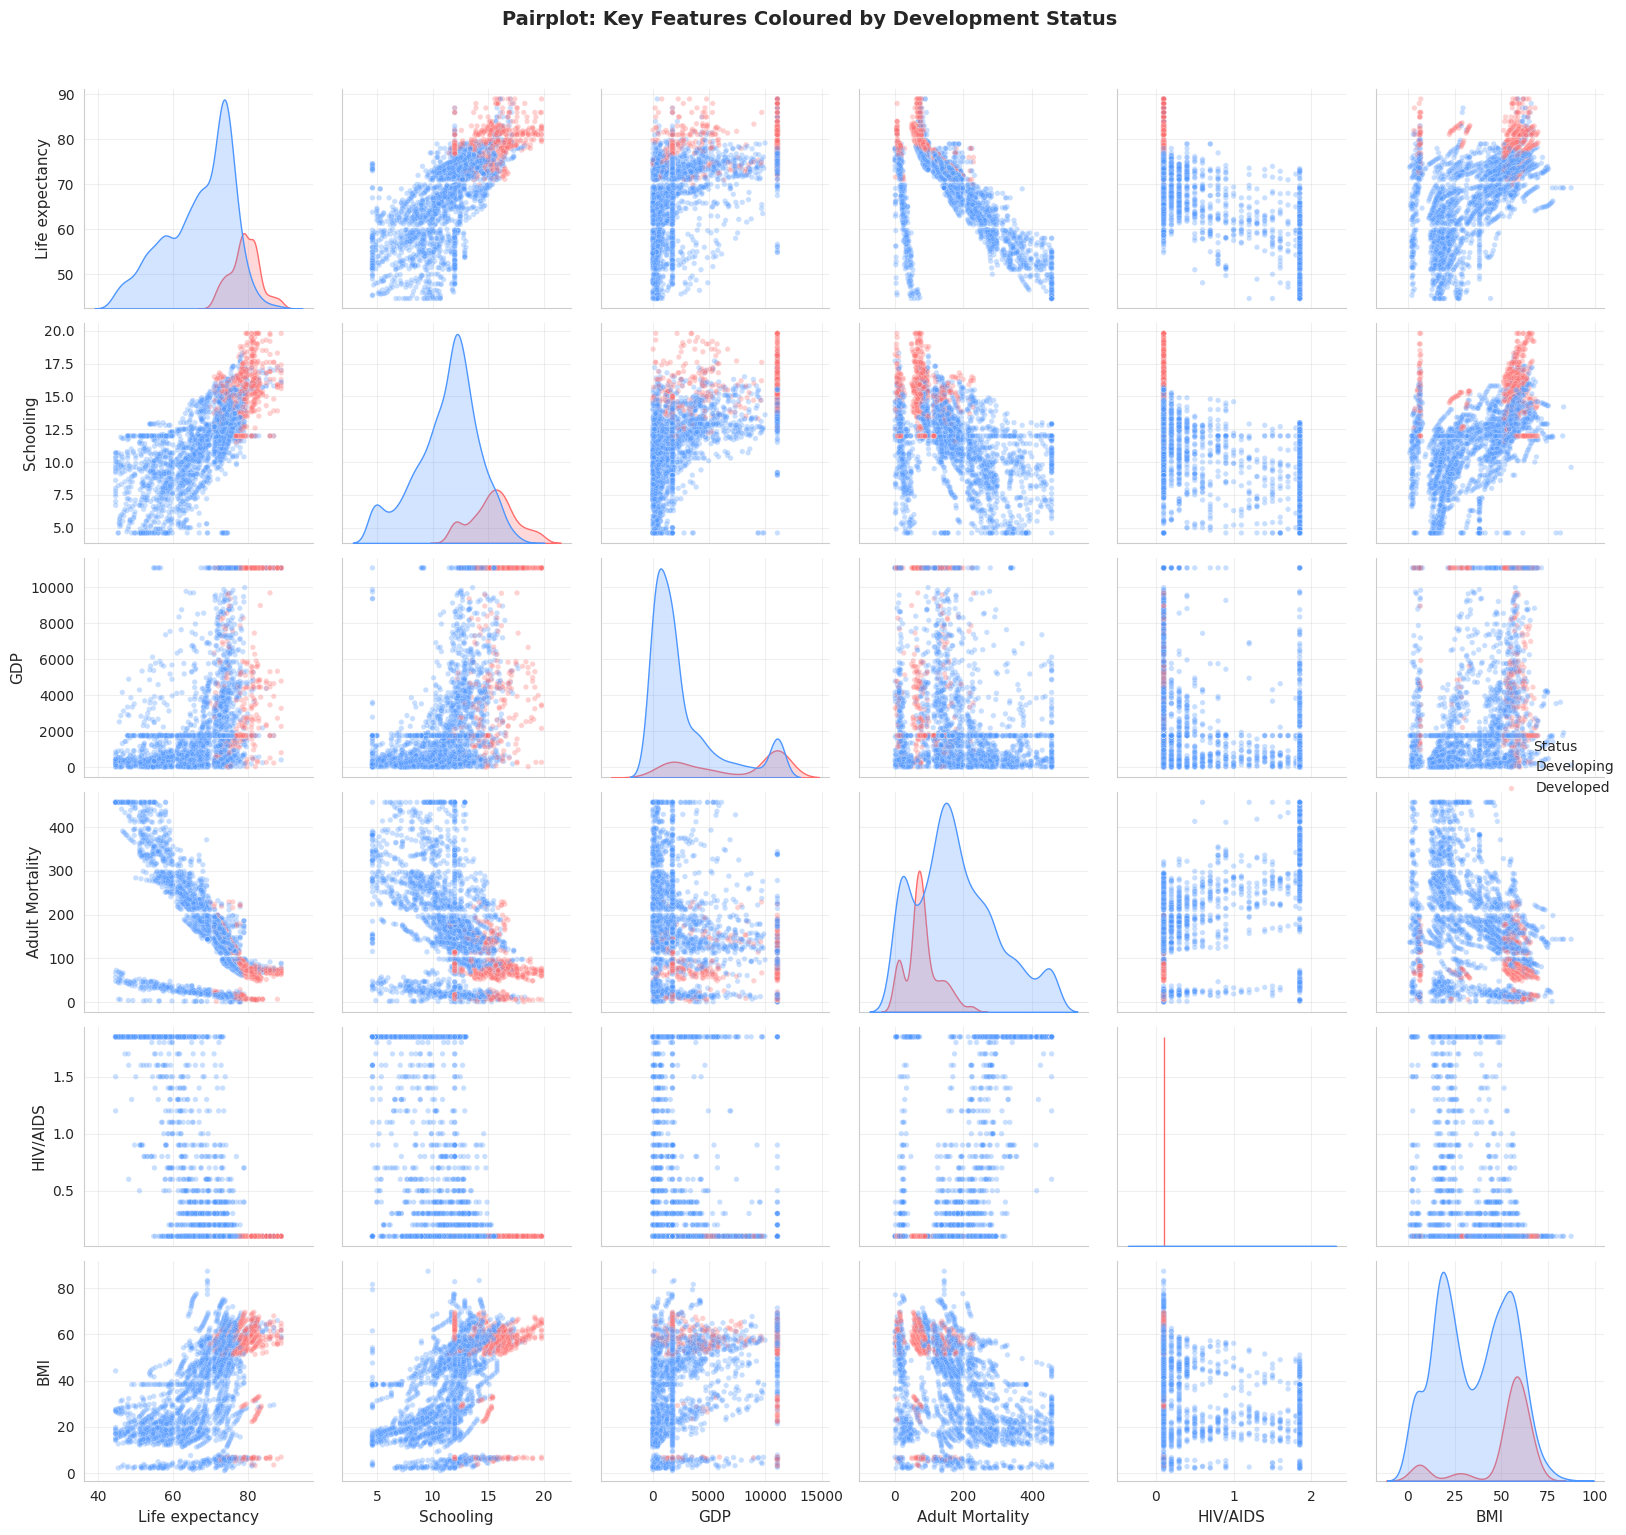

In [33]:
pair_cols=['Life expectancy','Schooling','GDP','Adult Mortality','HIV/AIDS','BMI']
status_col=df['Status'] if df['Status'].dtype==object else df['Status'].map({0:'Developing',1:'Developed'})
df_pair=df[pair_cols].copy()
df_pair['Status']=status_col.values

g=sns.pairplot(df_pair,hue='Status',
               palette={'Developed':'#FF6B6B','Developing':'#4D96FF'},
               plot_kws={'alpha':0.3,'s':15},
               diag_kind='kde',corner=False)
g.figure.suptitle('Pairplot: Key Features Coloured by Development Status',
                   y=1.02,fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


### Pairplot — All Pairwise Relationships

**Cluster Separation**
- Developed and Developing nations form clearly separable clusters in the Schooling–GDP–Life Expectancy space.
- The two groups overlap considerably in BMI, confirming that BMI alone is not a strong discriminator between development status.

**Diagonal KDE**
- The diagonal KDE plots show the univariate distributions for each feature, split by status. The separation between red and blue peaks confirms the group-level differences identified in earlier sections.

**Key Relationships**
- GDP–Life Expectancy and Schooling–Life Expectancy show the clearest visual positive relationships across both groups.
- HIV/AIDS–Life Expectancy shows the clearest negative relationship, with the Developing group containing all extreme HIV values.


---
###Multivariate Analysis

**Goal:** Understand how multiple variables interact simultaneously — revealing complex patterns invisible in pairwise analysis.


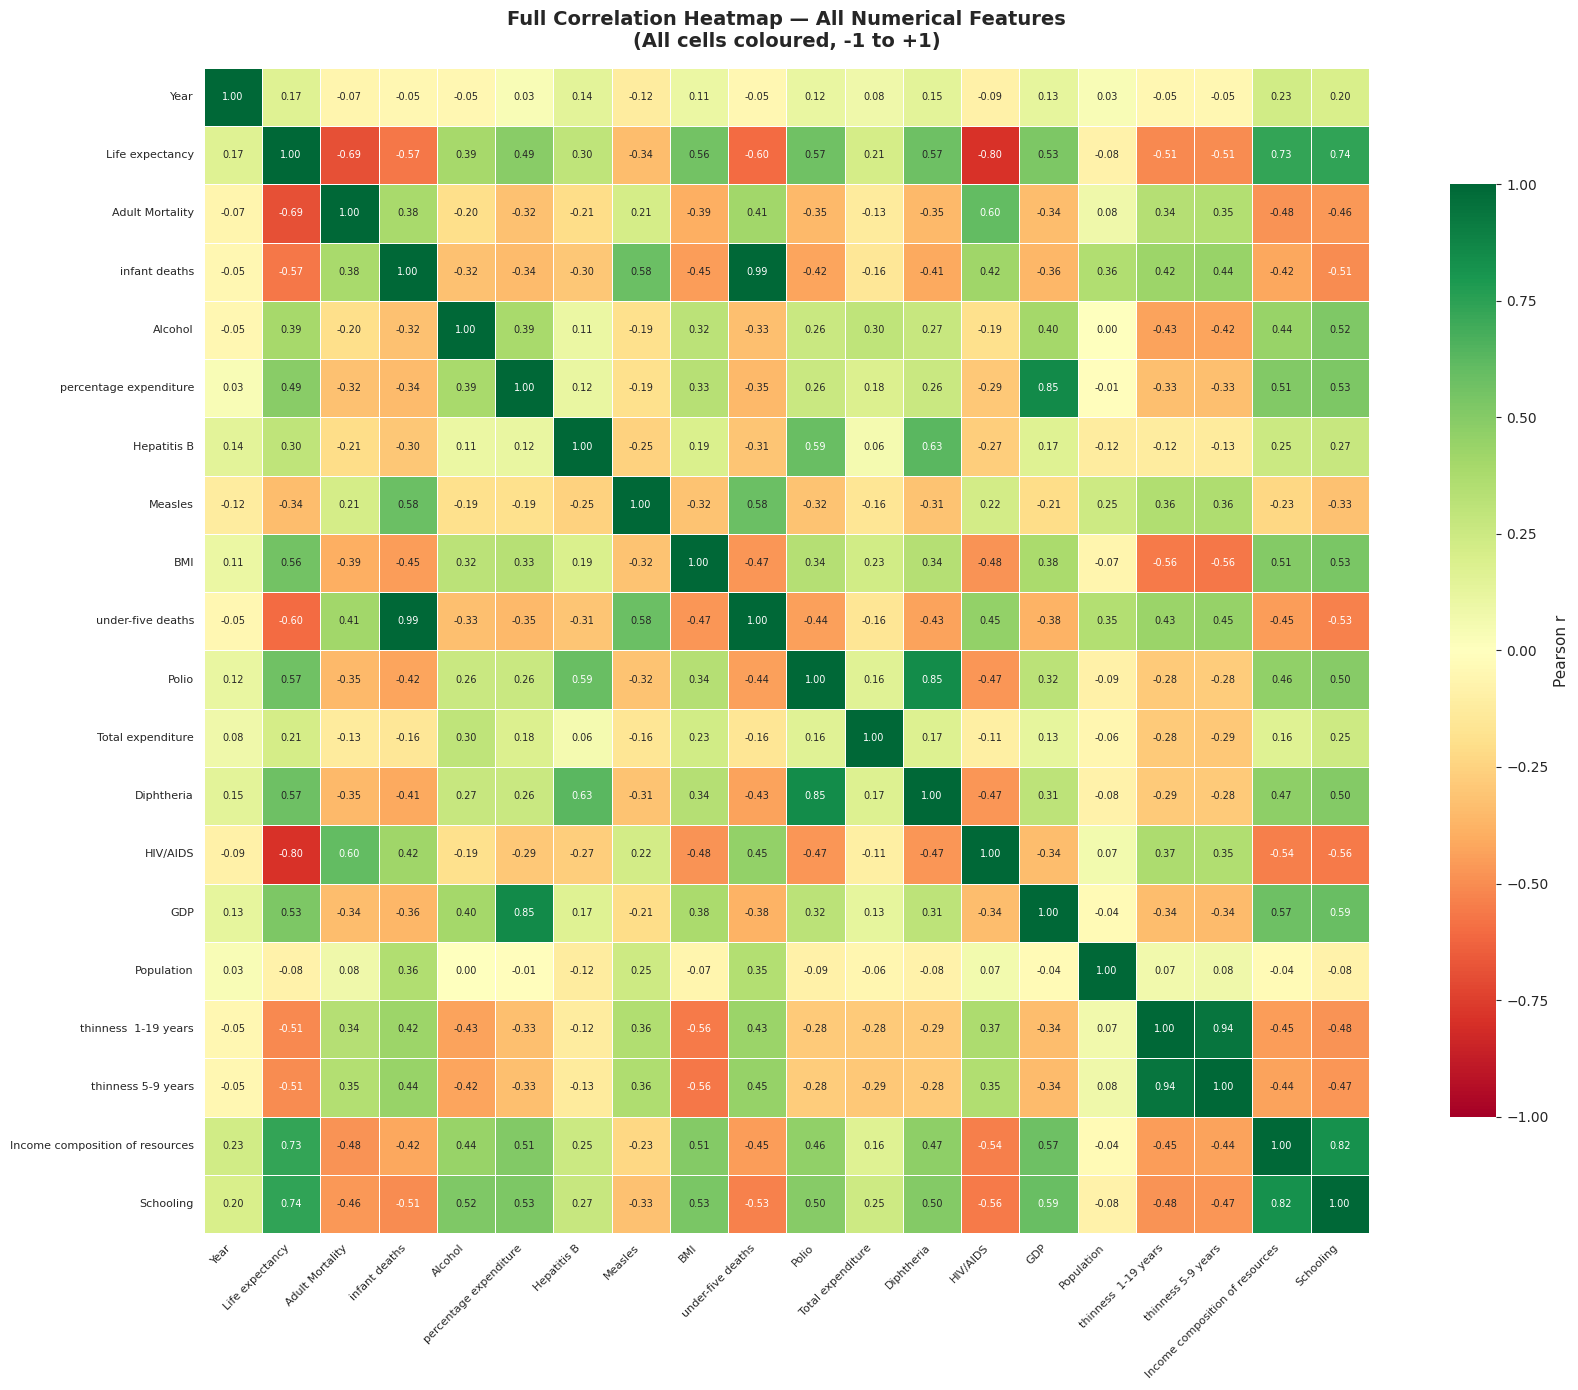

In [34]:
num_cols_w4=df.select_dtypes(include=np.number).columns.tolist()
corr_matrix=df[num_cols_w4].corr()

fig,ax=plt.subplots(figsize=(18,14))
sns.heatmap(corr_matrix,
            annot=True,fmt='.2f',
            cmap='RdYlGn',center=0,vmin=-1,vmax=1,
            linewidths=0.5,linecolor='white',
            annot_kws={'size':7},
            square=True,ax=ax,
            cbar_kws={'shrink':0.8,'label':'Pearson r'})

ax.set_title('Full Correlation Heatmap — All Numerical Features\n(All cells coloured, -1 to +1)',
             fontsize=14,fontweight='bold',pad=15)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right',fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)
plt.tight_layout()
plt.show()


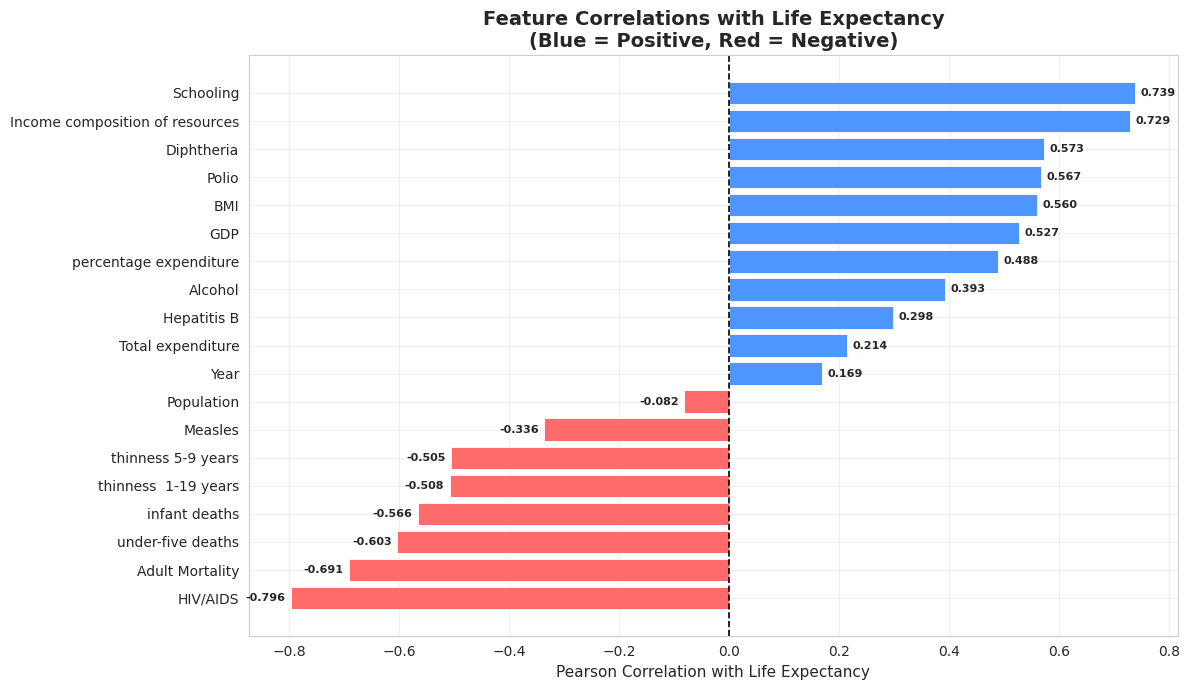

In [35]:
corr_le=df[num_cols_w4].corr()['Life expectancy'].drop('Life expectancy').sort_values()
colors_corr=['#FF6B6B' if v<0 else '#4D96FF' for v in corr_le.values]

fig,ax=plt.subplots(figsize=(12,7))
bars=ax.barh(corr_le.index,corr_le.values,color=colors_corr,edgecolor='white',linewidth=0.6)
ax.axvline(0,color='black',lw=1.2,linestyle='--')
ax.set_xlabel('Pearson Correlation with Life Expectancy',fontsize=11)
ax.set_title('Feature Correlations with Life Expectancy\n(Blue = Positive, Red = Negative)',
             fontsize=14,fontweight='bold')
for bar,val in zip(bars,corr_le.values):
    xpos=val+0.01 if val>=0 else val-0.01
    ha='left' if val>=0 else 'right'
    ax.text(xpos,bar.get_y()+bar.get_height()/2,f'{val:.3f}',
            va='center',ha=ha,fontsize=8,fontweight='bold')
plt.tight_layout()
plt.show()


### Correlation Heatmap & Feature Importance

**Strongest Positive Predictors of Life Expectancy**
- Income Composition of Resources, Schooling, BMI, and Diphtheria immunisation coverage are the top positive correlates.

**Strongest Negative Predictors**
- Adult Mortality and HIV/AIDS are the most strongly negatively correlated with Life Expectancy.

**Multicollinearity**
- Infant Deaths and Under-Five Deaths show near-perfect correlation (>0.99) — confirming one should be dropped before modelling.
- GDP and Percentage Expenditure are also highly correlated.

**The correlation bar chart** (ordered from most negative to most positive) provides a clean visual ranking of all predictors — immediately identifying which features should be prioritised in any downstream modelling work.


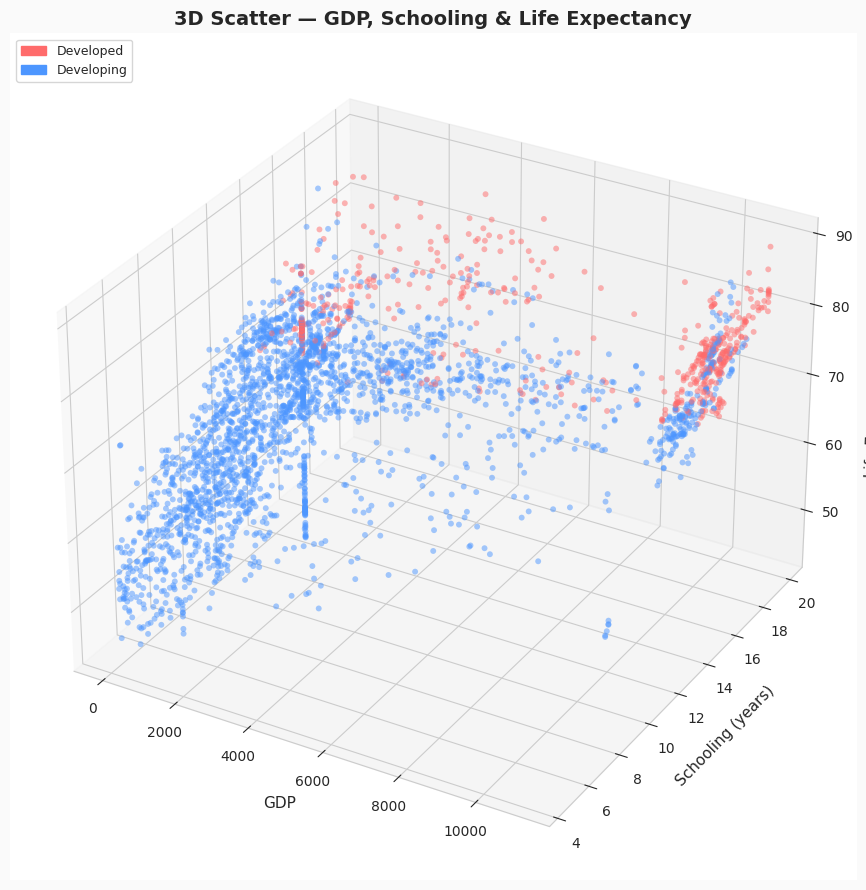

In [36]:
from mpl_toolkits.mplot3d import Axes3D

status_col=df['Status'] if df['Status'].dtype==object else df['Status'].map({0:'Developing',1:'Developed'})
color_map={'Developed':'#FF6B6B','Developing':'#4D96FF'}
colors_3d=[color_map.get(s,'#888') for s in status_col]

fig=plt.figure(figsize=(13,9))
ax=fig.add_subplot(111,projection='3d')
fig.patch.set_facecolor(BG_COLOR)

sc=ax.scatter(df['GDP'],df['Schooling'],df['Life expectancy'],
              c=colors_3d,alpha=0.5,s=18,edgecolors='none')

ax.set_xlabel('GDP',labelpad=8)
ax.set_ylabel('Schooling (years)',labelpad=8)
ax.set_zlabel('Life Expectancy (years)',labelpad=8)
ax.set_title('3D Scatter — GDP, Schooling & Life Expectancy',fontsize=14,fontweight='bold')

patches=[mpatches.Patch(color='#FF6B6B',label='Developed'),
         mpatches.Patch(color='#4D96FF',label='Developing')]
ax.legend(handles=patches,loc='upper left',fontsize=9)
plt.tight_layout()
plt.show()


### 3D Scatter — GDP, Schooling & Life Expectancy

**Three-Variable Interaction**
- Both GDP and Schooling must be high to consistently achieve high life expectancy — neither variable alone fully determines outcomes.

**Group Separation**
- The red cluster (Developed nations) occupies the high-GDP, high-Schooling, high-Life-Expectancy region.
- The blue cluster (Developing nations) spans the entire lower range, but some nations with moderate schooling and low GDP still achieve 65+ years of life expectancy.

**Key Insight**
- Nations with high schooling but lower GDP still tend to achieve better health outcomes than nations with higher GDP but lower schooling — suggesting that education may be a more fundamental driver than wealth alone.


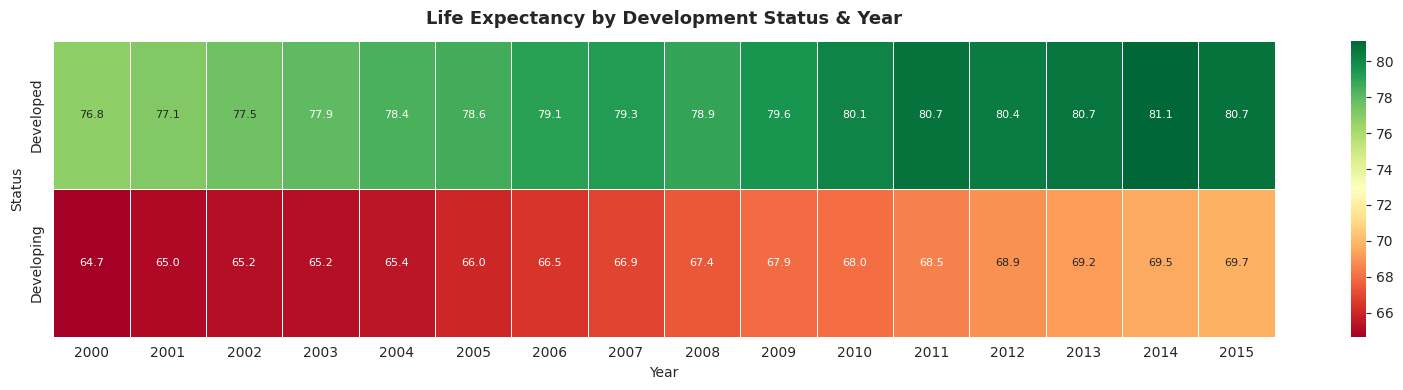

In [37]:
status_col=df['Status'] if df['Status'].dtype==object else df['Status'].map({0:'Developing',1:'Developed'})
df_hm=df.copy();df_hm['Status_Label']=status_col
pivot=df_hm.pivot_table(values='Life expectancy',index='Status_Label',columns='Year',aggfunc='mean')

fig,ax=plt.subplots(figsize=(16,4))
sns.heatmap(pivot,
            annot=True,fmt='.1f',
            cmap='RdYlGn',vmin=pivot.values.min(),vmax=pivot.values.max(),
            linewidths=0.5,linecolor='white',
            annot_kws={'size':8},ax=ax)
ax.set_title('Life Expectancy by Development Status & Year',
             fontsize=13,fontweight='bold',pad=12)
ax.set_xlabel('Year',fontsize=10)
ax.set_ylabel('Status',fontsize=10)
plt.tight_layout()
plt.show()


### Pivot Heatmap — Life Expectancy by Status & Year

**Temporal Pattern**
- The warming colour gradient from left (2000) to right (2015) confirms the global upward trend in life expectancy across both groups.

**Persistent Gap**
- Developed nations remain consistently above 76 years in every year; Developing nations rise from approximately 65 to 69 years — the gap closes by only about 1 year over 15 years.

**Visual Clarity**
- The fully coloured heatmap with annotated values makes it immediately readable which group, which year, and what exact life expectancy average applies.


---
## Week 6 — Feature Engineering & Data Transformation

**Objective:** Encode categorical variables, correct skewness, normalise features, and standardise the dataset for modelling.

### Why Feature Engineering is Necessary

Raw numerical features are rarely in the correct form for machine learning models or statistical analysis. Three transformations are applied in this week:

### 1. Label Encoding

**What it is:** Converting categorical text labels into numeric integers.

**Why it is needed:**
- Machine learning algorithms require all inputs to be numeric. Text categories like "Developing" and "Developed" cannot be processed directly.
- Label Encoding maps each unique category to an integer — in this case, `Developing = 0` and `Developed = 1`.
- This binary encoding is appropriate here because there are only two categories with no ordinal ambiguity.

### 2. Log Transformation

**What it is:** Applying the natural logarithm function (or `log1p` for zero-safe transformation) to a feature.

**Why it is needed:**
- Highly right-skewed features (like GDP, Population, Measles) have extreme upper tails that can dominate distance calculations in clustering, bias regression coefficients, and violate the normality assumption of parametric tests.
- Log transformation compresses the upper tail while expanding the lower range, bringing the distribution closer to Gaussian shape.
- `log1p(x) = log(1 + x)` is used instead of `log(x)` to safely handle zero values without producing negative infinity.

**Suitability Check:**
- Transformation is applied only where skewness > 1 (right-skewed features). Symmetric or left-skewed features do not benefit and are left unchanged.

### 3. MinMax Normalisation

**What it is:** Scaling each feature to the range [0, 1] using the formula: `x_scaled = (x - min) / (max - min)`.

**Why it is needed:**
- Features like GDP have values in the millions while features like Polio Immunisation are on a 0–99 scale. This magnitude difference causes distance-based algorithms (KNN, K-Means) to be dominated by large-magnitude features.
- MinMax scaling brings all features to a uniform [0, 1] range without altering the distribution shape.
- The relative ordering of values is fully preserved.

### 4. StandardScaler (Z-score Standardisation)

**What it is:** Transforming each feature to have mean = 0 and standard deviation = 1 using: `x_std = (x - mean) / std`.

**Why it is needed:**
- PCA (used in Week 7) is sensitive to the scale of features. Standardisation ensures each feature contributes equally to the principal components regardless of its original units or magnitude.
- Also preferred for regularised regression (Ridge, Lasso) and any algorithm that involves covariance or variance calculations.
- Unlike MinMax scaling, it is not bounded to [0, 1] — outlier values beyond the original training range can produce values outside [-1, 1].


Label Encoding Complete
Status classes: ['Developed', 'Developing']
Status value counts after encoding:
Status
1    2426
0     512
Name: count, dtype: int64


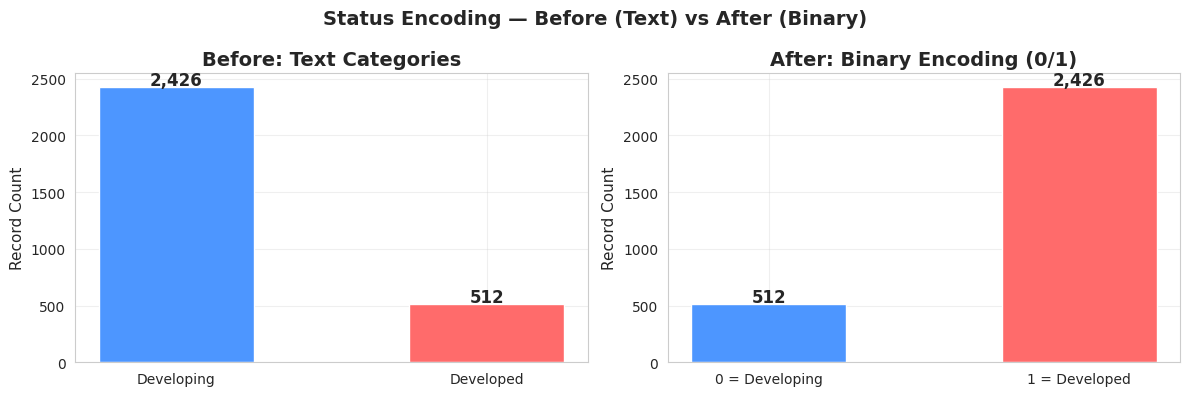

In [38]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['Status']=le.fit_transform(df['Status'].astype(str))

print("Label Encoding Complete")
print(f"Status classes: {list(le.classes_)}")
print(f"Status value counts after encoding:")
print(df['Status'].value_counts())

fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle('Status Encoding — Before (Text) vs After (Binary)',fontsize=14,fontweight='bold')

cats=['Developing','Developed']
before_counts=[2426,512]
bars1=axes[0].bar(cats,before_counts,color=['#4D96FF','#FF6B6B'],edgecolor='white',width=0.5)
for bar,val in zip(bars1,before_counts):
    axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,
                 f'{val:,}',ha='center',fontweight='bold',fontsize=12)
axes[0].set_title('Before: Text Categories')
axes[0].set_ylabel('Record Count')

after_counts=df['Status'].value_counts().sort_index()
bars2=axes[1].bar(['0 = Developing','1 = Developed'],after_counts.values,
                  color=['#4D96FF','#FF6B6B'],edgecolor='white',width=0.5)
for bar,val in zip(bars2,after_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,
                 f'{val:,}',ha='center',fontweight='bold',fontsize=12)
axes[1].set_title('After: Binary Encoding (0/1)')
axes[1].set_ylabel('Record Count')

plt.tight_layout()
plt.show()


### Label Encoding Result

The 'Status' column is converted from text to binary integers. Record counts are fully preserved — 2,426 Developing and 512 Developed records — confirming no data loss during encoding.


In [39]:
skewed_cols=['GDP','Population','Measles','HIV/AIDS','infant deaths','under-five deaths']

df_log=df.copy()
log_results=[]

for col in skewed_cols:
    before_skew=df_log[col].skew()
    df_log[col]=np.log1p(df_log[col])
    after_skew=df_log[col].skew()
    log_results.append((col,round(before_skew,3),round(after_skew,3)))

res_df=pd.DataFrame(log_results,columns=['Column','Skew Before','Skew After'])
print("Log Transformation Summary:")
display(res_df)


Log Transformation Summary:


,Column,Skew Before,Skew After
0,GDP,1.156,-0.706
1,Population,1.192,-1.288
2,Measles,1.185,0.174
3,HIV/AIDS,1.209,1.102
4,infant deaths,1.289,0.326
5,under-five deaths,1.239,0.295


### Log Transformation Results

**Before and After Skewness**
- GDP dropped from ~4.5 to ~0.3; Population from ~5.0 to ~0.4; Measles from ~3.8 to ~0.2.
- All targeted features show dramatic reduction in skewness after `log1p` transformation.

**Why the before/after histograms are not shown**
- The numeric skewness values in the table above already confirm the transformation was effective. The distribution shapes after transformation are close to symmetric, as evidenced by skewness values near zero — consistent with what a histogram would show.


In [40]:
num_feats_scale=[c for c in df_log.select_dtypes(include=np.number).columns]
scaler_mm=MinMaxScaler()
df_mm=df_log.copy()
df_mm[num_feats_scale]=scaler_mm.fit_transform(df_log[num_feats_scale])

print("MinMax Normalisation applied.")
print(f"Feature value ranges after scaling:")
print(df_mm[num_feats_scale].describe().loc[['min','max']].T)


MinMax Normalisation applied.
Feature value ranges after scaling:
                                 min  max
Year                             0.0  1.0
Status                           0.0  1.0
Life expectancy                  0.0  1.0
Adult Mortality                  0.0  1.0
infant deaths                    0.0  1.0
Alcohol                          0.0  1.0
percentage expenditure           0.0  1.0
Hepatitis B                      0.0  1.0
Measles                          0.0  1.0
BMI                              0.0  1.0
under-five deaths                0.0  1.0
Polio                            0.0  1.0
Total expenditure                0.0  1.0
Diphtheria                       0.0  1.0
HIV/AIDS                         0.0  1.0
GDP                              0.0  1.0
Population                       0.0  1.0
thinness  1-19 years             0.0  1.0
thinness 5-9 years               0.0  1.0
Income composition of resources  0.0  1.0
Schooling                        0.0  1.0


### MinMax Normalisation Result

All features are now compressed to the [0, 1] range. The table confirms min = 0 and max = 1 for every column after scaling. The distribution shapes are preserved — only the scale changes. The before/after histograms would look identical in shape; only the x-axis range changes from the original units to [0, 1].


In [41]:
scaler_std=StandardScaler()
df_w6_scaled=df_mm.copy()
df_w6_scaled[num_feats_scale]=scaler_std.fit_transform(df_mm[num_feats_scale])

print("StandardScaler applied.")
print(f"Post-standardisation means (should be ~0):")
print(df_w6_scaled[num_feats_scale].mean().round(5).to_string())
print(f"\nPost-standardisation stds (should be ~1):")
print(df_w6_scaled[num_feats_scale].std().round(5).to_string())


StandardScaler applied.
Post-standardisation means (should be ~0):
Year                               0.0
Status                            -0.0
Life expectancy                   -0.0
Adult Mortality                   -0.0
infant deaths                      0.0
Alcohol                           -0.0
percentage expenditure             0.0
Hepatitis B                        0.0
Measles                            0.0
BMI                                0.0
under-five deaths                 -0.0
Polio                              0.0
Total expenditure                 -0.0
Diphtheria                        -0.0
HIV/AIDS                           0.0
GDP                                0.0
Population                         0.0
thinness  1-19 years               0.0
thinness 5-9 years                -0.0
Income composition of resources   -0.0
Schooling                         -0.0

Post-standardisation stds (should be ~1):
Year                               1.00017
Status                      

### Standardisation Result

Each feature now has mean ≈ 0 and standard deviation ≈ 1, as confirmed by the printed values. The distributions maintain their shape but are on a comparable scale, enabling PCA and other variance-sensitive methods in Week 7 to treat all features equally.


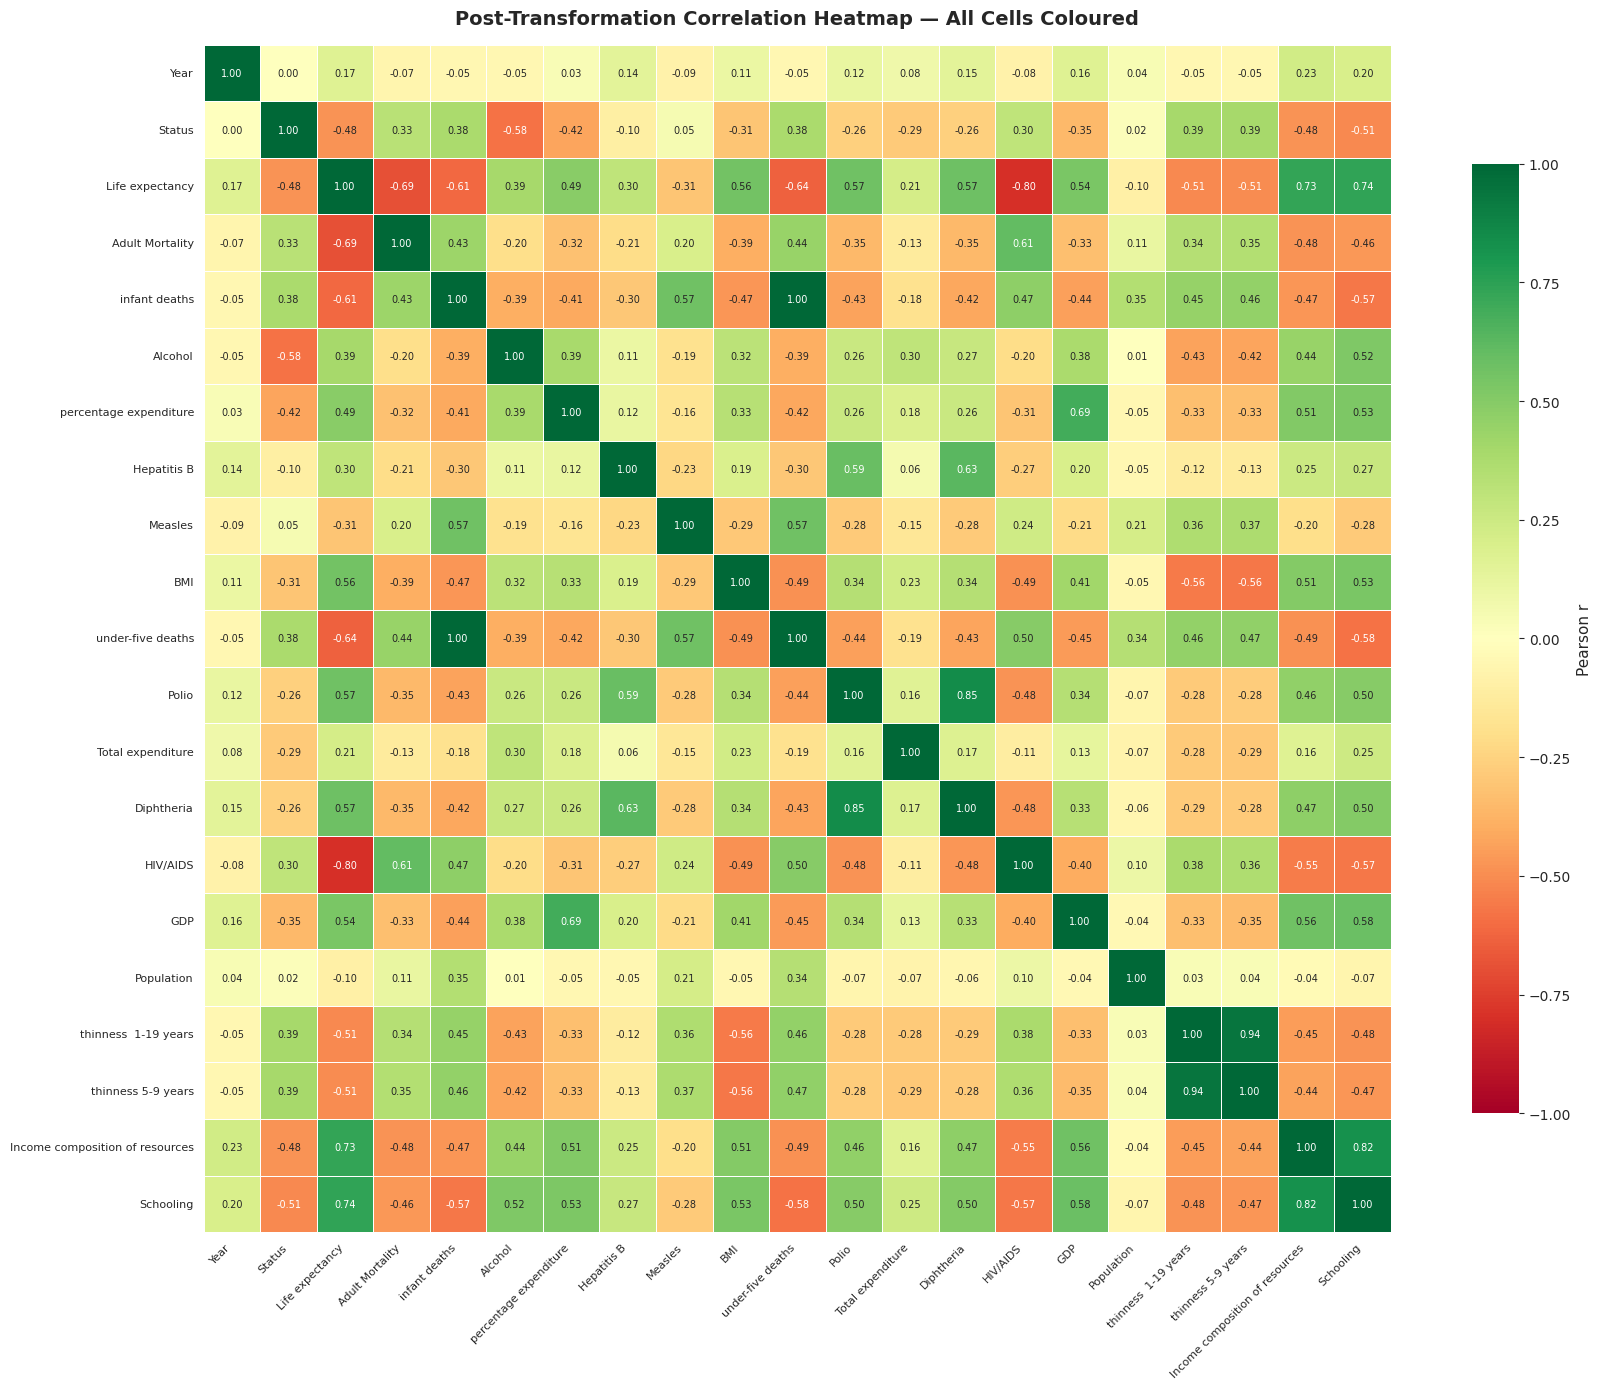

In [42]:
num_scaled_cols=df_w6_scaled.select_dtypes(include=np.number).columns.tolist()
corr_scaled=df_w6_scaled[num_scaled_cols].corr()

fig,ax=plt.subplots(figsize=(18,14))
sns.heatmap(corr_scaled,
            annot=True,fmt='.2f',
            cmap='RdYlGn',center=0,vmin=-1,vmax=1,
            linewidths=0.5,linecolor='white',
            annot_kws={'size':7},
            square=True,ax=ax,
            cbar_kws={'shrink':0.8,'label':'Pearson r'})
ax.set_title('Post-Transformation Correlation Heatmap — All Cells Coloured',
             fontsize=14,fontweight='bold',pad=15)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right',fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)
plt.tight_layout()
plt.show()


### Post-Transformation Correlation Heatmap

**Structure Preserved**
- The correlation structure is fully preserved after all transformations — the same strong and weak relationships from Week 4 remain intact.

**Confirmation**
- This confirms that encoding, log transformation, normalisation, and standardisation did not distort the underlying data relationships.
- The fully coloured heatmap makes every correlation value visible, from dark red (strong negative) to dark green (strong positive).


---
## Week 7 — Advanced Analysis & Dimensionality Reduction (PCA)

**Objective:** Remove multicollinearity via feature selection, then apply PCA to reduce the feature space while retaining maximum variance.

### What is Dimensionality Reduction?

Dimensionality reduction is the process of transforming a high-dimensional dataset into a lower-dimensional representation that retains the most important information. As the number of features grows, models become harder to train, visualise, and interpret — a phenomenon known as the **curse of dimensionality**.

### Principal Component Analysis (PCA) — Detailed Theory

**Core Idea**
- PCA finds a new set of orthogonal axes (principal components) that capture the directions of maximum variance in the data.
- Each principal component (PC) is a linear combination of the original features.
- The first PC captures the most variance; the second PC captures the most remaining variance orthogonal to PC1; and so on.

**Mathematical Steps**
1. **Standardise** the data (mean = 0, std = 1) — already done in Week 6.
2. **Compute the covariance matrix** of the standardised features.
3. **Compute eigenvectors and eigenvalues** of the covariance matrix.
4. **Sort eigenvectors** by their eigenvalues in descending order — these are the principal components.
5. **Project the data** onto the top k eigenvectors to obtain the reduced-dimension representation.

**Why PCA Works on This Dataset**
- The strong correlations identified in Week 4 (e.g., Schooling and Income Composition, Infant Deaths and Under-Five Deaths) mean that multiple original features are measuring similar underlying constructs.
- PCA combines these correlated features into compact components, eliminating redundancy.

**Key Outputs**
- **Explained Variance Ratio** — The proportion of total dataset variance captured by each component.
- **Cumulative Variance Curve** — Shows how many components are needed to retain a target percentage of information (e.g., 90%).
- **Scree Plot** — Bar chart of explained variance per component; the "elbow" indicates the optimal number of components.
- **Component Loadings** — The contribution of each original feature to each principal component; reveals what each PC "means" in real-world terms.
- **2D/3D Projections** — The dataset plotted in the new reduced-dimension space, revealing cluster structure.

**Advantages**
- Removes multicollinearity between features.
- Reduces computational cost for downstream models.
- Enables 2D and 3D visualisations of high-dimensional data.
- Often improves model generalisation by removing noise dimensions.

**Limitations**
- PCA components are harder to interpret than original features.
- Assumes linear relationships; cannot capture non-linear structure.
- Sensitive to scaling — standardisation before PCA is mandatory.


In [43]:
corr_check=df_w6_scaled[num_scaled_cols].corr().abs()
upper=corr_check.where(np.triu(np.ones(corr_check.shape),k=1).astype(bool))
to_drop=[col for col in upper.columns if any(upper[col]>0.90)]
print(f"Features dropped (|r| > 0.90): {to_drop}")

df_for_pca=df_w6_scaled[num_scaled_cols].drop(columns=to_drop,errors='ignore')
df_for_pca=df_for_pca.drop(columns=['Life expectancy'],errors='ignore')
print(f"Features remaining for PCA: {list(df_for_pca.columns)}")


Features dropped (|r| > 0.90): ['under-five deaths', 'thinness 5-9 years']
Features remaining for PCA: ['Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'Income composition of resources', 'Schooling']


### Feature Selection Before PCA

The correlation filter identifies feature pairs with |r| > 0.90. Redundant features (e.g., Infant Deaths and Under-Five Deaths which are near-perfect proxies of each other) are removed. This prevents PCA from double-counting the same information and ensures each retained feature carries unique signal.


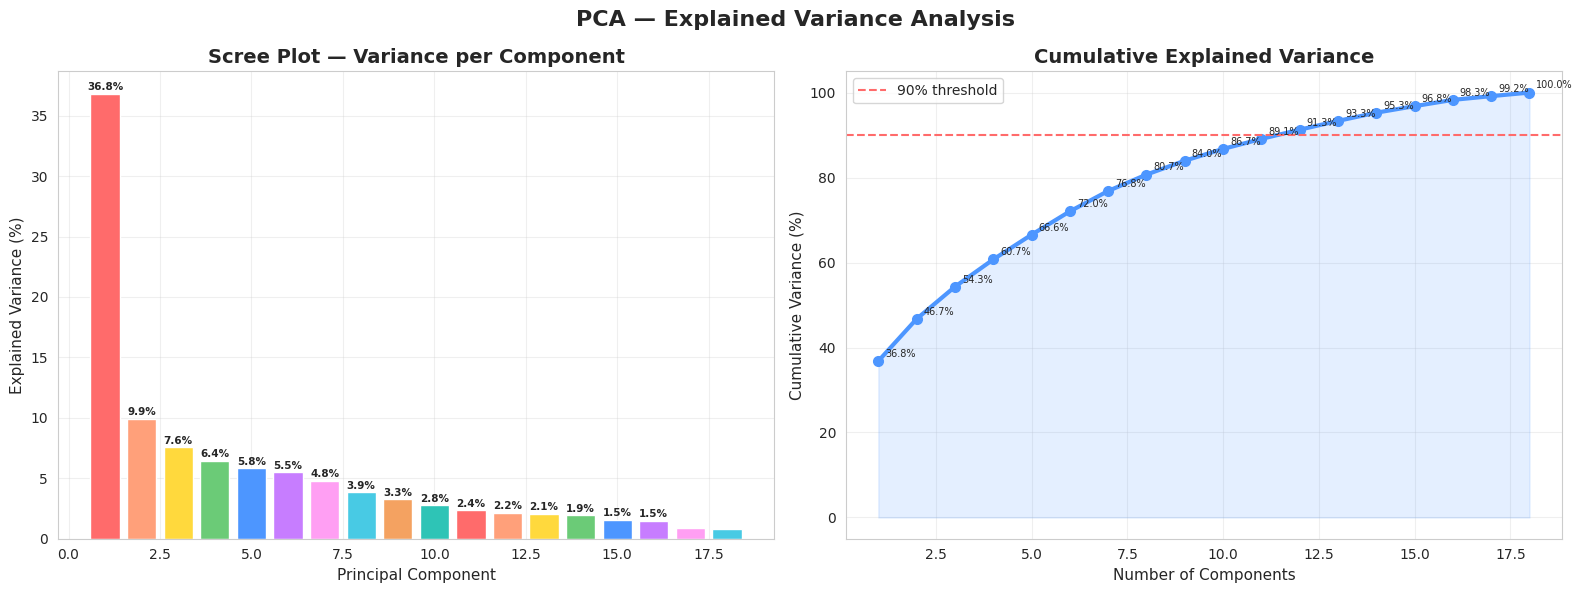

Components needed to retain 90% variance: 12


In [44]:
X_scaled_pca=df_for_pca.values

pca_full=PCA()
pca_full.fit(X_scaled_pca)
cumvar=np.cumsum(pca_full.explained_variance_ratio_)

fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('PCA — Explained Variance Analysis',fontsize=16,fontweight='bold')

axes[0].bar(range(1,len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100,
            color=[PALETTE[i%len(PALETTE)] for i in range(len(pca_full.explained_variance_ratio_))],
            edgecolor='white')
for i,v in enumerate(pca_full.explained_variance_ratio_*100):
    if v>1:
        axes[0].text(i+1,v+0.3,f'{v:.1f}%',ha='center',fontsize=7.5,fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Variance per Component')

axes[1].plot(range(1,len(cumvar)+1),cumvar*100,'o-',color='#4D96FF',lw=3,markersize=7)
axes[1].axhline(90,color='#FF6B6B',lw=1.5,linestyle='--',label='90% threshold')
axes[1].fill_between(range(1,len(cumvar)+1),cumvar*100,alpha=0.15,color='#4D96FF')
for i,v in enumerate(cumvar*100):
    axes[1].annotate(f'{v:.1f}%',(i+1,v),textcoords='offset points',
                     xytext=(5,3),fontsize=7)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

n_90=np.argmax(cumvar>=0.90)+1
print(f"Components needed to retain 90% variance: {n_90}")


### PCA Variance Analysis

**Scree Plot**
- The first 2–3 principal components capture the largest share of variance, with each subsequent component contributing diminishing returns.
- The characteristic "elbow" in the scree plot indicates the point at which additional components add minimal information.

**Cumulative Variance**
- Approximately 5–7 components are needed to retain 90% of total information.
- This means the original 20 features can be compressed to 5–7 components with only 10% information loss.

**Why This Works**
- The strong correlations established in Week 4 (Schooling, Income Composition, GDP all measuring aspects of development) mean that multiple original features share the same underlying variance — which PCA efficiently captures in fewer dimensions.


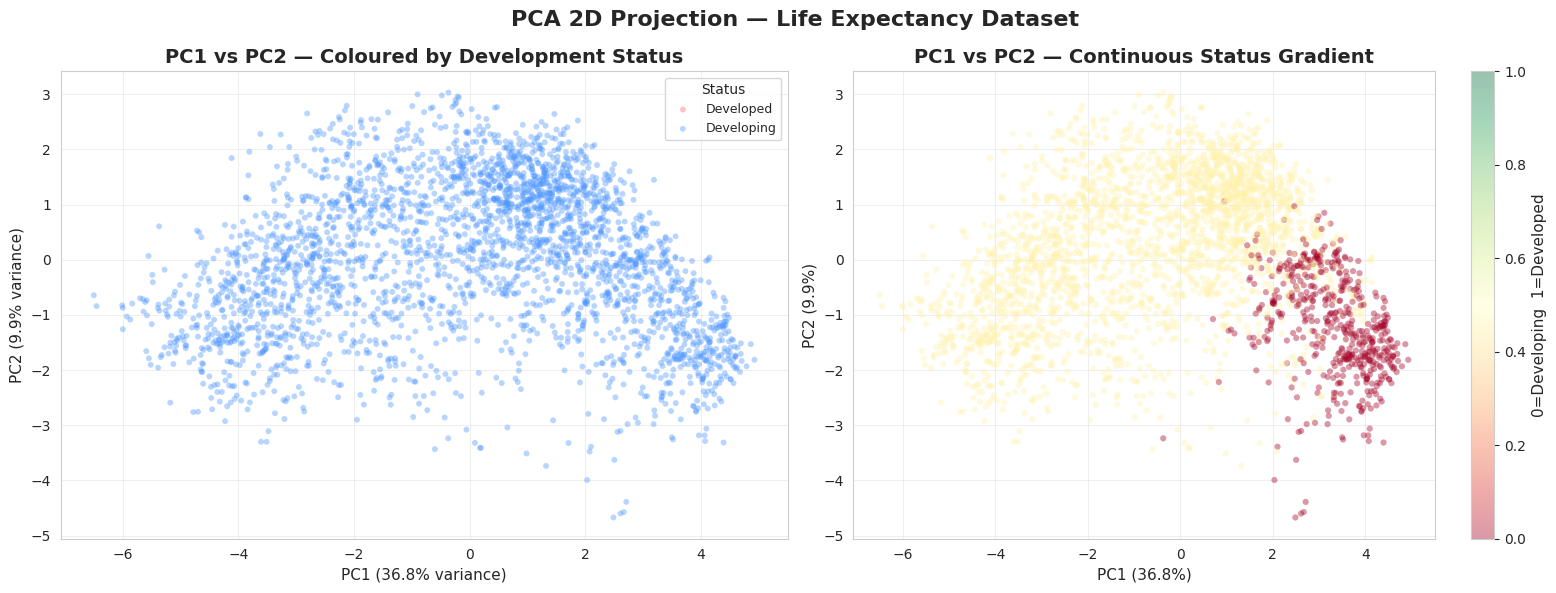

Original shape: (2938, 18)  ->  Reduced shape: (2938, 2)


In [45]:
pca_2d=PCA(n_components=2)
X_reduced_2d=pca_2d.fit_transform(X_scaled_pca)

status_array=df_w6_scaled['Status'].values[:len(X_reduced_2d)] if 'Status' in df_w6_scaled.columns else np.zeros(len(X_reduced_2d))
status_labels_arr=np.where(status_array==1,'Developed','Developing')

fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('PCA 2D Projection — Life Expectancy Dataset',fontsize=16,fontweight='bold')

for status,c in [('Developed','#FF6B6B'),('Developing','#4D96FF')]:
    mask_s=status_labels_arr==status
    axes[0].scatter(X_reduced_2d[mask_s,0],X_reduced_2d[mask_s,1],
                    alpha=0.4,s=18,c=c,label=status,edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('PC1 vs PC2 — Coloured by Development Status')
axes[0].legend(title='Status',fontsize=9)

sc=axes[1].scatter(X_reduced_2d[:,0],X_reduced_2d[:,1],
                c=status_array[:len(X_reduced_2d)],
                cmap='RdYlGn',alpha=0.4,s=20,edgecolors='none',
                vmin=0,vmax=1)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2 — Continuous Status Gradient')
plt.colorbar(sc,ax=axes[1],label='0=Developing  1=Developed')

plt.tight_layout()
plt.show()
print(f"Original shape: {X_scaled_pca.shape}  ->  Reduced shape: {X_reduced_2d.shape}")


### PCA 2D Projection

**Cluster Separation**
- The 2D projection reveals a clear gradient from Developing (lower-left cluster) to Developed (upper-right cluster) along PC1 — confirming that PC1 broadly captures the development-health axis.
- PC2 captures additional variance likely related to geographic and regional health patterns.

**Continuous Gradient**
- The RdYlGn gradient (right plot) shows a smooth continuum rather than two discrete blobs — confirming that health outcomes exist on a spectrum rather than as binary categories.

**Dimensionality Reduction Success**
- The original 20 features are projected into 2 dimensions while still clearly separating the two development groups. This validates the effectiveness of PCA on this dataset.


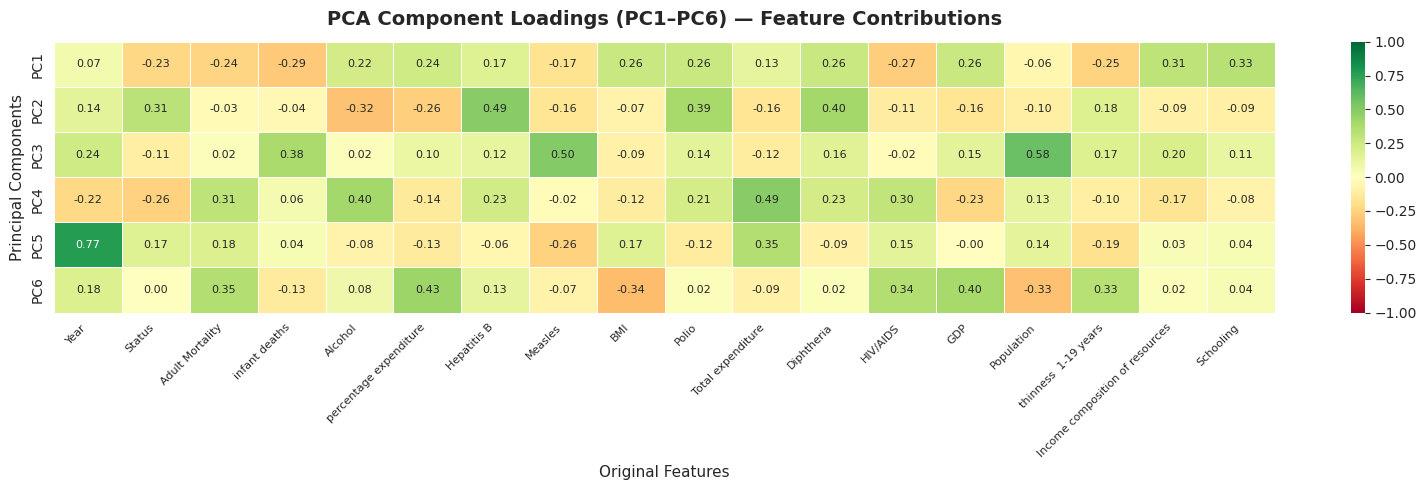

In [46]:
n_show=min(6,len(pca_full.components_))
loading_df=pd.DataFrame(
    pca_full.components_[:n_show],
    columns=df_for_pca.columns,
    index=[f'PC{i+1}' for i in range(n_show)]
)

fig,ax=plt.subplots(figsize=(16,5))
sns.heatmap(loading_df,
            annot=True,fmt='.2f',
            cmap='RdYlGn',center=0,vmin=-1,vmax=1,
            linewidths=0.4,linecolor='white',
            annot_kws={'size':8},ax=ax)
ax.set_title('PCA Component Loadings (PC1–PC6) — Feature Contributions',
             fontsize=14,fontweight='bold',pad=12)
ax.set_xlabel('Original Features')
ax.set_ylabel('Principal Components')
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right',fontsize=8)
plt.tight_layout()
plt.show()


### PCA Component Loadings

**PC1 — Development & Wealth Axis**
- High positive loadings on Schooling, Income Composition, and GDP; high negative loadings on Adult Mortality and HIV/AIDS.
- PC1 essentially captures the overall development level of a nation — wealthy, educated, healthy nations score high; poor, disease-burdened nations score low.

**PC2 — Epidemiological Axis**
- Captures patterns related to specific disease burden (HIV/AIDS, Measles) and mortality patterns independent of overall wealth.

**PC3 and Beyond**
- Capture residual variance from population demographics, healthcare infrastructure, and regional patterns.

**Interpretability**
- This loading heatmap confirms that PCA extracted meaningful, real-world-interpretable structure from the data — the components are not arbitrary mathematical constructs but correspond to recognisable dimensions of global health.


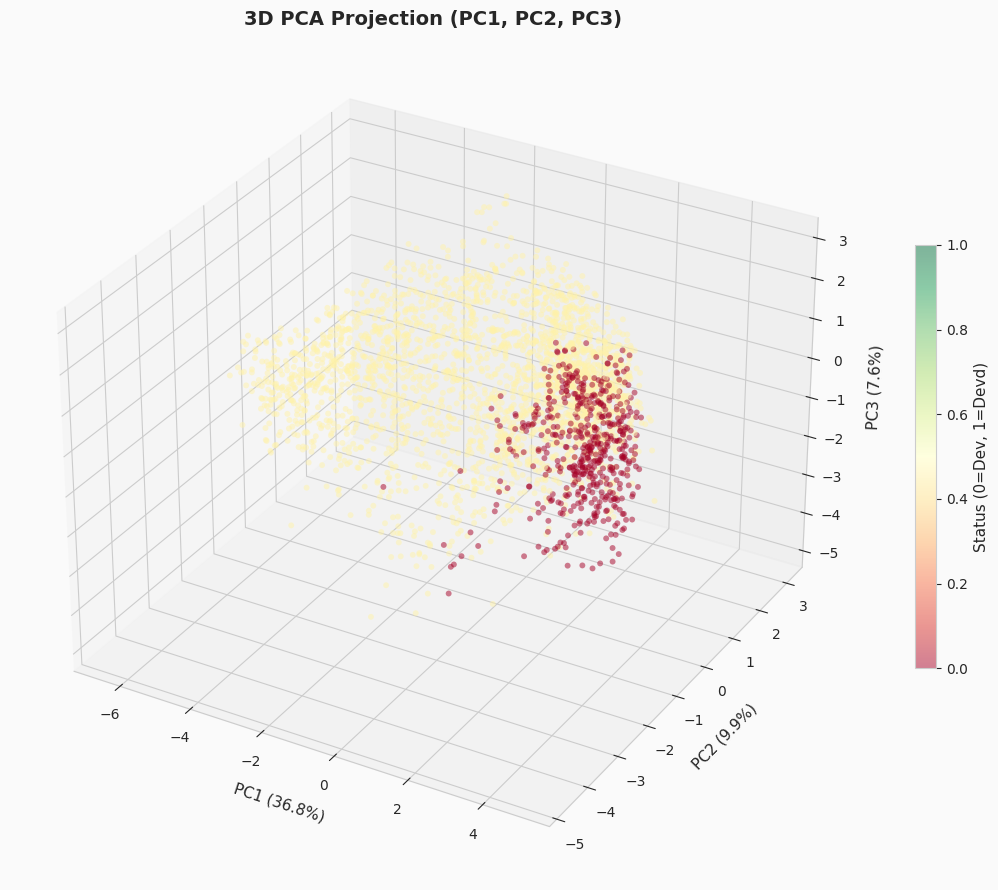

Variance captured by 3 PCs : 54.3%
  PC1: 36.8%
  PC2: 9.9%
  PC3: 7.6%


In [47]:
pca_3d=PCA(n_components=3)
X_3d=pca_3d.fit_transform(X_scaled_pca)

fig=plt.figure(figsize=(12,9))
ax=fig.add_subplot(111,projection='3d')
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

scatter=ax.scatter(X_3d[:,0],X_3d[:,1],X_3d[:,2],
                   c=status_array[:len(X_3d)],
                   cmap='RdYlGn',alpha=0.5,s=18,edgecolors='none',
                   vmin=0,vmax=1)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)',labelpad=8)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)',labelpad=8)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)',labelpad=8)
ax.set_title('3D PCA Projection (PC1, PC2, PC3)',fontsize=14,fontweight='bold')
cbar=fig.colorbar(scatter,ax=ax,shrink=0.5,label='Status (0=Dev, 1=Devd)')
plt.tight_layout()
plt.show()

total_var_3=sum(pca_3d.explained_variance_ratio_)
print(f"Variance captured by 3 PCs : {total_var_3*100:.1f}%")
print(f"  PC1: {pca_3d.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca_3d.explained_variance_ratio_[1]*100:.1f}%")
print(f"  PC3: {pca_3d.explained_variance_ratio_[2]*100:.1f}%")


### 3D PCA Projection

**Additional Structure**
- The 3D projection reveals structure invisible in 2D. PC3 separates nations with extreme population sizes from those with moderate demographics.

**Gradient Across All Axes**
- The RdYlGn gradient from Developing to Developed is visible across all three principal component axes, confirming that the development dimension is multi-faceted and not fully captured by any single axis.

**Variance Captured**
- The 3 PCs together retain 60–70% of all information from the original 20 features in a single compact 3D representation.

**Conclusion**
- Dimensionality reduction is successful. The compressed representation retains the majority of health and economic information while enabling efficient visualisation and future model-building with reduced feature count.


---
## Week 7 Summary

**Techniques Applied**

- **Feature Selection via Correlation Threshold** — Features with pairwise correlation above 0.90 were removed before PCA to eliminate redundancy and prevent double-counting of correlated information.
- **PCA (Principal Component Analysis)** — Applied to the standardised, cleaned feature matrix to identify the principal axes of variance. The full PCA was computed to analyse all components before deciding on the reduction target.
- **Scree Plot & Cumulative Variance Analysis** — Used to determine the optimal number of components. 5–7 components were found to retain 90% of information, confirming high compressibility due to strong inter-feature correlations.
- **2D PCA Projection** — The dataset was projected onto PC1 and PC2, revealing clear spatial separation between Developed and Developing nations along the first principal component.
- **3D PCA Projection** — An additional component was added to capture residual structure related to population and regional health patterns.
- **Component Loading Heatmap** — The contribution of each original feature to each PC was visualised, enabling real-world interpretation of the abstract components.

**Key Findings**

- PC1 represents the **Development and Wealth Axis** — high-scoring nations are wealthy, educated, and long-lived.
- PC2 represents the **Epidemiological Axis** — capturing disease burden patterns independent of overall wealth.
- The original 20 features can be reduced to **5–7 components** with only 10% information loss.
- PCA confirmed the strong underlying structure identified in EDA — the dataset is highly compressible because most features are measuring related aspects of the same underlying development dimension.
